In [37]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

RESULTS_DIR = "../../logs/mnist/threshold_research"


def load_merged_results(tobj_dir):
    with open(os.path.join(tobj_dir, "merged_results.json")) as f:
        return json.load(f)


def load_training_metrics(tobj_dir):
    """Load and concatenate training_metrics.json across all seeds."""
    metrics = {}
    seed_dirs = sorted(d for d in os.listdir(tobj_dir) if d.startswith("seed_"))
    for seed_dir in seed_dirs:
        path = os.path.join(tobj_dir, seed_dir, "training_metrics.json")
        with open(path) as f:
            seed_metrics = json.load(f)
        for key, values in seed_metrics.items():
            metrics.setdefault(key, []).extend(values)
    return metrics


def plot_distribution_stats(t_objectives, training, metric_key, metric_label):
    """Plot mean-std relationship, CV, skewness/kurtosis, and normality test."""
    means = np.array([np.mean(training[t][metric_key]) for t in t_objectives])
    stds = np.array([np.std(training[t][metric_key]) for t in t_objectives])
    cvs = [s / m if m != 0 else 0 for s, m in zip(stds, means)]
    skews = [stats.skew(training[t][metric_key]) for t in t_objectives]
    kurts = [stats.kurtosis(training[t][metric_key]) for t in t_objectives]
    shapiro_ps = [stats.shapiro(training[t][metric_key]).pvalue for t in t_objectives]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Distribution statistics: {metric_label}", fontsize=13, y=1.01)

    # Mean vs Std scatter with linear fit
    ax = axes[0, 0]
    ax.scatter(means, stds, c=t_objectives, cmap="viridis", s=60, edgecolors="black", zorder=3)
    for m, s, t in zip(means, stds, t_objectives):
        ax.annotate(f"{t:.2f}", (m, s), textcoords="offset points", xytext=(5, 5), fontsize=7)
    slope, intercept, r_val, _, _ = stats.linregress(means, stds)
    fit_x = np.array([means.min(), means.max()])
    ax.plot(fit_x, slope * fit_x + intercept, "--", color="red", linewidth=1,
            label=f"fit: std = {slope:.4f} * mean + {intercept:.2f}  (R²={r_val**2:.3f})")
    ax.set_xlabel(f"Mean {metric_label.lower()}")
    ax.set_ylabel(f"Std {metric_label.lower()}")
    ax.set_title("Mean vs Std")
    ax.legend(fontsize=8)

    # Coefficient of variation
    ax = axes[0, 1]
    ax.plot(t_objectives, cvs, "o-", color="steelblue")
    ax.set_xlabel("t_objective")
    ax.set_ylabel("CV (std / mean)")
    ax.set_title("Coefficient of variation")

    # Skewness and kurtosis
    ax = axes[1, 0]
    ax.plot(t_objectives, skews, "o-", label="Skewness", color="steelblue")
    ax.plot(t_objectives, kurts, "s-", label="Excess kurtosis", color="coral")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("t_objective")
    ax.set_ylabel("Value")
    ax.set_title("Skewness and kurtosis")
    ax.legend()

    # Shapiro-Wilk p-values (log scale)
    ax = axes[1, 1]
    ax.semilogy(t_objectives, shapiro_ps, "o-", color="steelblue")
    ax.axhline(0.05, color="red", linestyle="--", linewidth=0.8, label="p = 0.05")
    ax.set_xlabel("t_objective")
    ax.set_ylabel("Shapiro-Wilk p-value")
    ax.set_title("Normality test (Shapiro-Wilk)")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [38]:
tobj_dirs = sorted(
    (d for d in os.listdir(RESULTS_DIR) if d.startswith("tobj_")),
    key=lambda d: float(d.split("_")[1]),
)
t_objectives = [float(d.split("_")[1]) for d in tobj_dirs]

merged = {}
training = {}
for tobj, dirname in zip(t_objectives, tobj_dirs):
    full_path = os.path.join(RESULTS_DIR, dirname)
    merged[tobj] = load_merged_results(full_path)
    training[tobj] = load_training_metrics(full_path)

print(f"Loaded {len(t_objectives)} t_objectives: {t_objectives}")
print(f"Seeds per t_objective: {len(merged[t_objectives[0]]['seeds'])}")
print(f"Neurons per t_objective (all seeds): {len(training[t_objectives[0]]['threshold_final'])}")

Loaded 13 t_objectives: [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.875, 0.9, 0.95]
Seeds per t_objective: 5
Neurons per t_objective (all seeds): 1280


# Experiment 1: Training with varying t_objective

256-neuron single-layer SNNs trained across 12 t_objectives (0.4–0.95) with 5 seeds each.

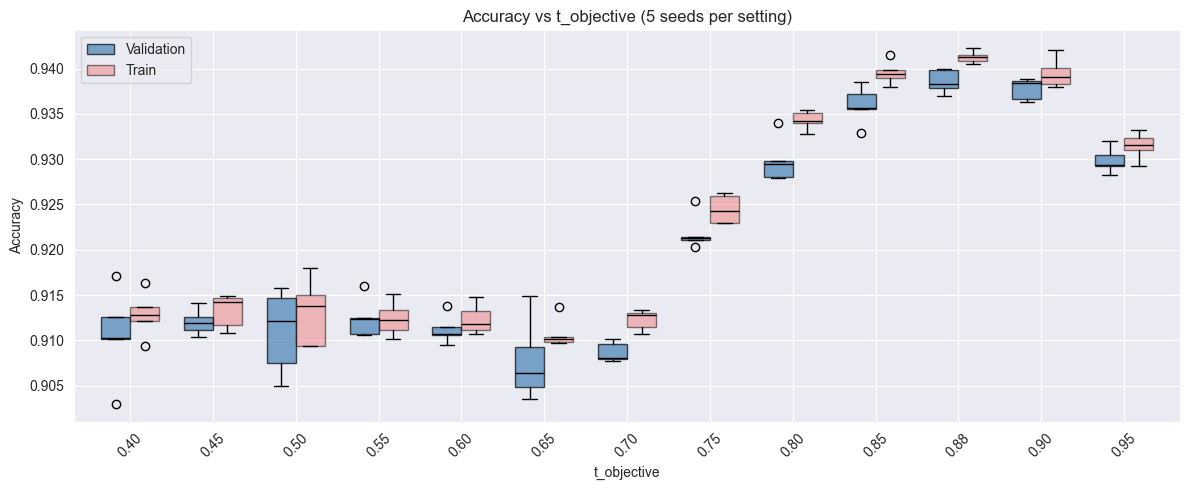

In [39]:
# Plot 1: Validation accuracy boxplot across t_objectives
val_accuracies = [merged[t]["validation"]["accuracy"] for t in t_objectives]
train_accuracies = [merged[t]["train"]["accuracy"] for t in t_objectives]

fig, ax = plt.subplots(figsize=(12, 5))
positions = np.arange(len(t_objectives))

bp_val = ax.boxplot(
    val_accuracies, positions=positions, widths=0.35,
    patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="black"),
)
bp_train = ax.boxplot(
    train_accuracies, positions=positions + 0.35, widths=0.35,
    patch_artist=True, boxprops=dict(facecolor="lightcoral", alpha=0.5),
    medianprops=dict(color="black"),
)

ax.set_xticks(positions + 0.175)
ax.set_xticklabels([f"{t:.2f}" for t in t_objectives], rotation=45)
ax.set_xlabel("t_objective")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs t_objective (5 seeds per setting)")
ax.legend(
    [bp_val["boxes"][0], bp_train["boxes"][0]],
    ["Validation", "Train"],
)
plt.tight_layout()
plt.show()

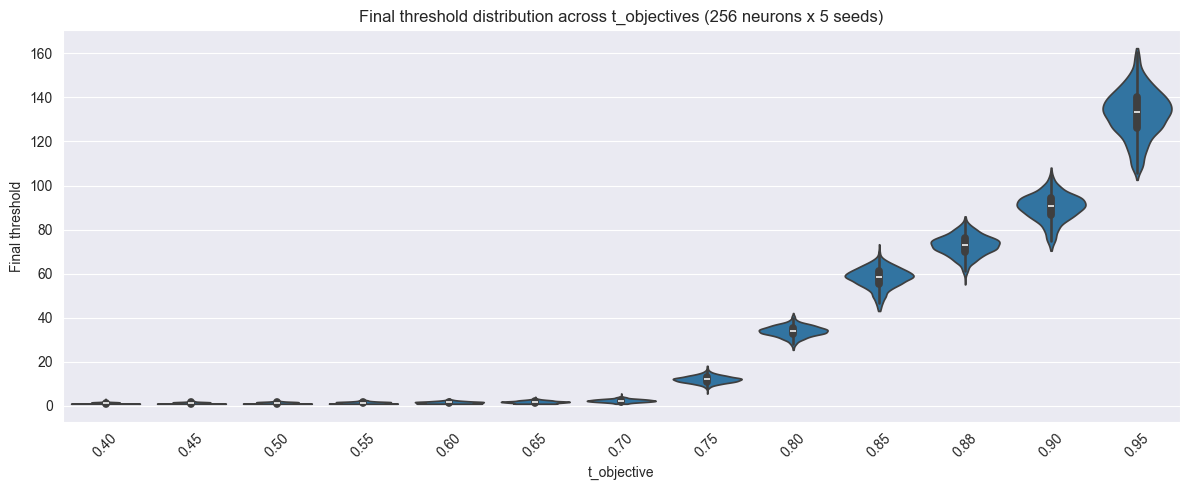

In [40]:
# Plot 2: Final threshold distribution (violin) across t_objectives
threshold_data = []
threshold_labels = []
for t in t_objectives:
    values = training[t]["threshold_final"]
    threshold_data.extend(values)
    threshold_labels.extend([f"{t:.2f}"] * len(values))

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    x=threshold_labels, y=threshold_data, ax=ax,
    inner="box", cut=0, density_norm="width",
)
ax.set_xlabel("t_objective")
ax.set_ylabel("Final threshold")
ax.set_title("Final threshold distribution across t_objectives (256 neurons x 5 seeds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

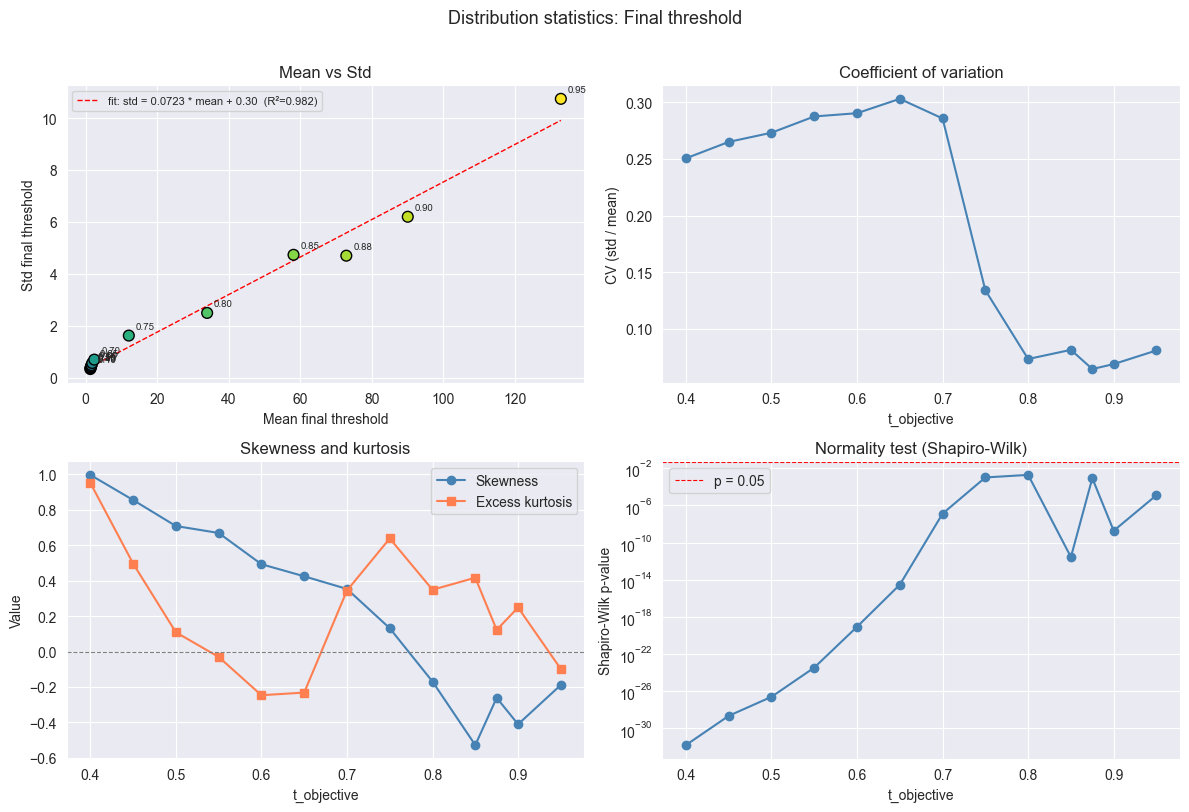

In [41]:
plot_distribution_stats(t_objectives, training, "threshold_final", "Final threshold")

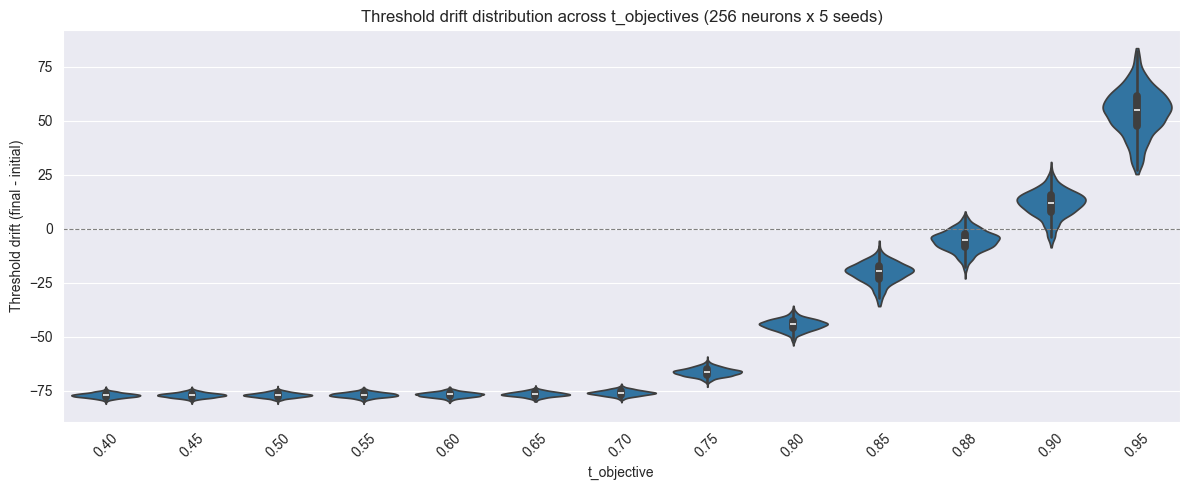

In [42]:
# Plot 3: Threshold drift distribution across t_objectives
drift_data = []
drift_labels = []
for t in t_objectives:
    values = training[t]["threshold_drift"]
    drift_data.extend(values)
    drift_labels.extend([f"{t:.2f}"] * len(values))

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    x=drift_labels, y=drift_data, ax=ax,
    inner="box", cut=0, density_norm="width",
)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("t_objective")
ax.set_ylabel("Threshold drift (final - initial)")
ax.set_title("Threshold drift distribution across t_objectives (256 neurons x 5 seeds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

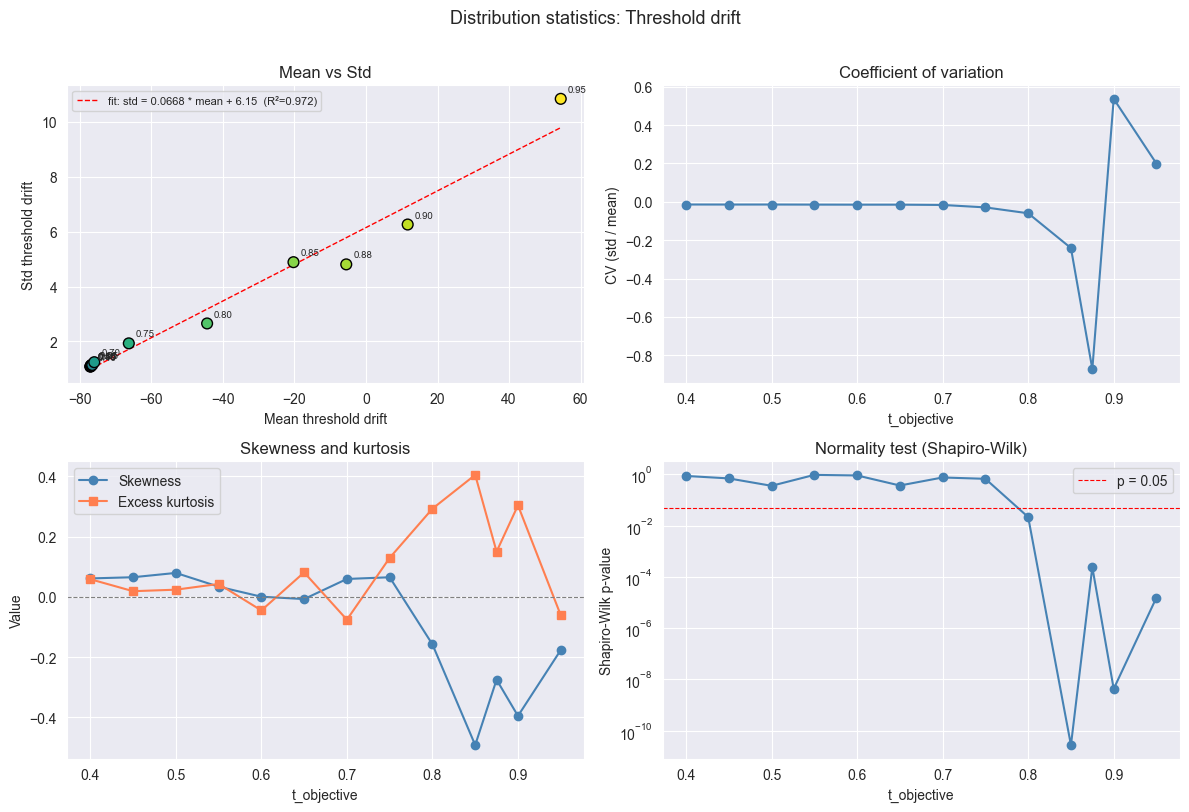

In [43]:
plot_distribution_stats(t_objectives, training, "threshold_drift", "Threshold drift")

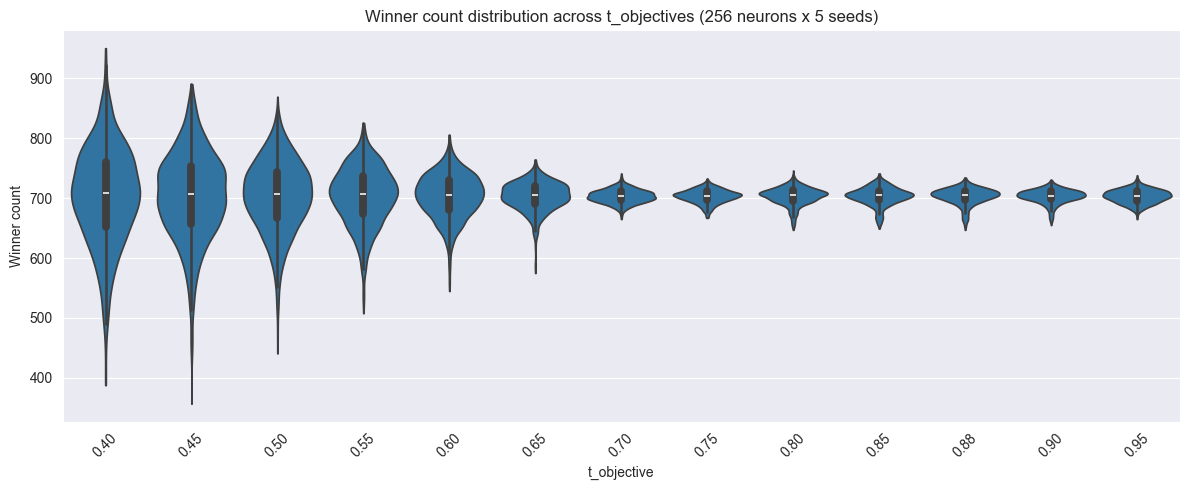

In [44]:
# Plot 4: Winner count distribution across t_objectives
winner_data = []
winner_labels = []
for t in t_objectives:
    values = training[t]["winner_counts"]
    winner_data.extend(values)
    winner_labels.extend([f"{t:.2f}"] * len(values))

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    x=winner_labels, y=winner_data, ax=ax,
    inner="box", cut=0, density_norm="width",
)
ax.set_xlabel("t_objective")
ax.set_ylabel("Winner count")
ax.set_title("Winner count distribution across t_objectives (256 neurons x 5 seeds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

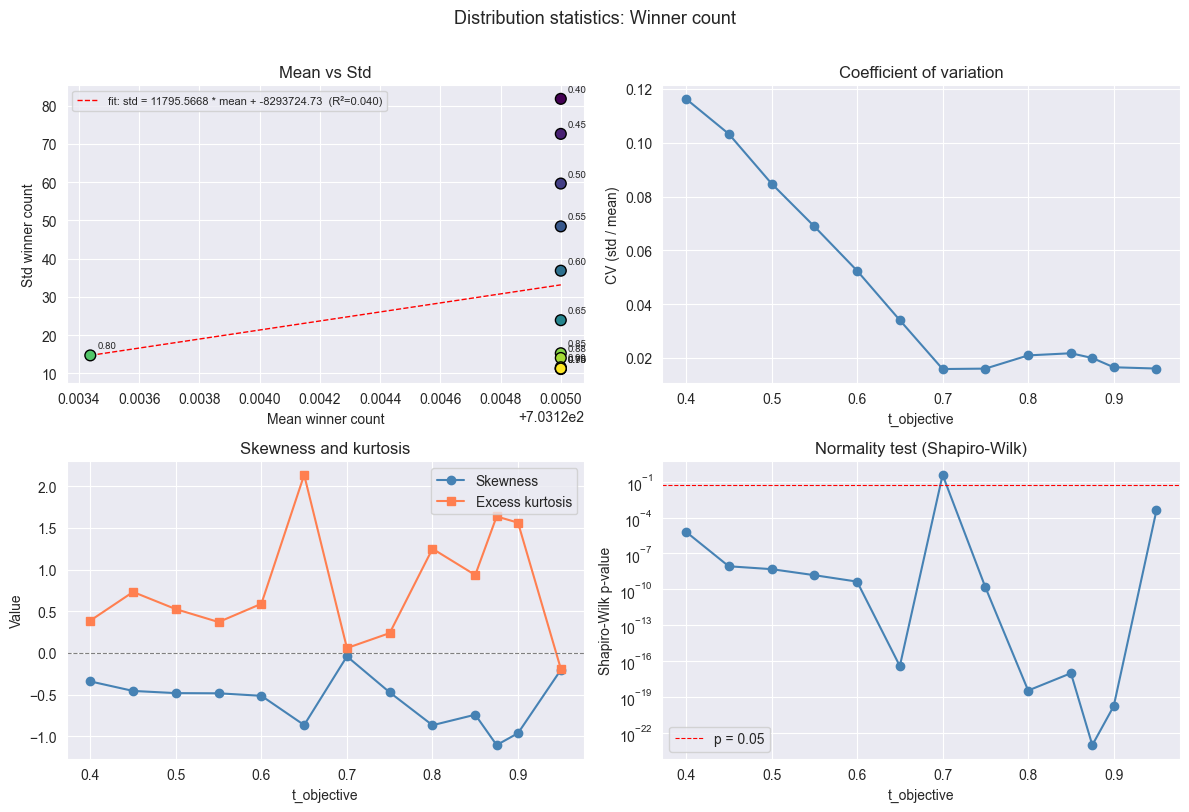

In [45]:
plot_distribution_stats(t_objectives, training, "winner_counts", "Winner count")

/var/folders/s2/81dpl6dd6xq1m2_npzc7ngcw0000gp/T/ipykernel_94345/1944480782.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


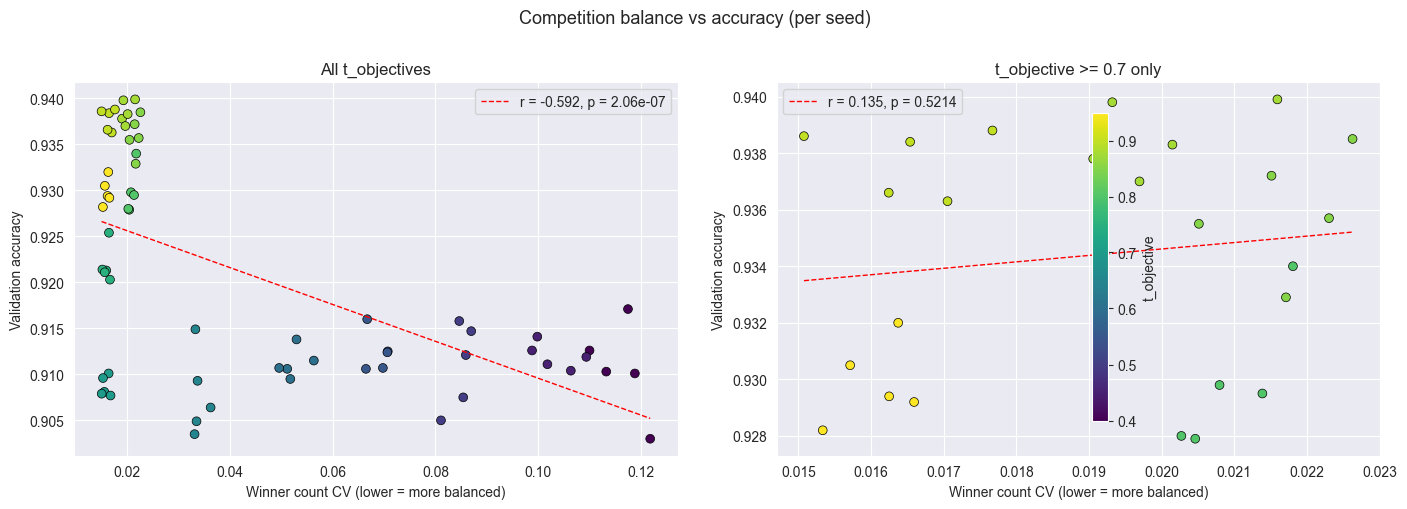

In [46]:
# Plot 4b: Correlation between winner count balance and validation accuracy
# Per-seed: CV of winner counts (lower = more balanced) vs accuracy
winner_cvs = []
val_accs = []
seed_tobjs = []

for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    for i, seed_dir in enumerate(seed_dirs):
        with open(os.path.join(tobj_path, seed_dir, "training_metrics.json")) as f:
            tm = json.load(f)
        wc = np.array(tm["winner_counts"])
        winner_cvs.append(np.std(wc) / np.mean(wc))
        val_accs.append(merged[tobj]["validation"]["accuracy"][i])
        seed_tobjs.append(tobj)

winner_cvs = np.array(winner_cvs)
val_accs = np.array(val_accs)
seed_tobjs = np.array(seed_tobjs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all t_objectives
ax = axes[0]
r_all, p_all = stats.pearsonr(winner_cvs, val_accs)
sc = ax.scatter(winner_cvs, val_accs, c=seed_tobjs, cmap="viridis", s=40, edgecolors="black", linewidths=0.5)
slope, intercept, _, _, _ = stats.linregress(winner_cvs, val_accs)
fit_x = np.array([winner_cvs.min(), winner_cvs.max()])
ax.plot(fit_x, slope * fit_x + intercept, "--", color="red", linewidth=1,
        label=f"r = {r_all:.3f}, p = {p_all:.2e}")
ax.set_xlabel("Winner count CV (lower = more balanced)")
ax.set_ylabel("Validation accuracy")
ax.set_title("All t_objectives")
ax.legend()

# Right: t_objective > 0.7 only
ax = axes[1]
mask = seed_tobjs > 0.75
r_high, p_high = stats.pearsonr(winner_cvs[mask], val_accs[mask])
sc = ax.scatter(winner_cvs[mask], val_accs[mask], c=seed_tobjs[mask], cmap="viridis", s=40,
                edgecolors="black", linewidths=0.5, vmin=seed_tobjs.min(), vmax=seed_tobjs.max())
slope, intercept, _, _, _ = stats.linregress(winner_cvs[mask], val_accs[mask])
fit_x = np.array([winner_cvs[mask].min(), winner_cvs[mask].max()])
ax.plot(fit_x, slope * fit_x + intercept, "--", color="red", linewidth=1,
        label=f"r = {r_high:.3f}, p = {p_high:.4f}")
ax.set_xlabel("Winner count CV (lower = more balanced)")
ax.set_ylabel("Validation accuracy")
ax.set_title("t_objective >= 0.7 only")
ax.legend()

fig.colorbar(sc, ax=axes, label="t_objective", shrink=0.8)
fig.suptitle("Competition balance vs accuracy (per seed)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Experiment 2: Weight scaling sensitivity

For each trained model, weights are scaled by factors [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.05, 1.1] and re-evaluated. Measures how robust learned representations are to weight perturbation across t_objectives.

In [47]:
# Load weight scaling results (per t_objective, averaged across available seeds)
scaling = {}
for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_results = []
    for seed_dir in sorted(os.listdir(tobj_path)):
        if not seed_dir.startswith("seed_"):
            continue
        ws_path = os.path.join(tobj_path, seed_dir, "weight_scaling.json")
        if os.path.exists(ws_path):
            with open(ws_path) as f:
                seed_results.append(json.load(f))
    if seed_results:
        scaling[tobj] = seed_results

scale_factors = sorted(float(k) for k in scaling[next(iter(scaling))][0]["factors"])[3:]
print(f"Loaded weight scaling for {len(scaling)}/{len(t_objectives)} t_objectives")
print(f"Scale factors: {scale_factors}")
for t, results in scaling.items():
    print(f"  t_obj={t:.2f}: {len(results)} seeds")

Loaded weight scaling for 13/13 t_objectives
Scale factors: [0.85, 0.9, 0.95, 0.97, 0.98, 1.02, 1.03, 1.05, 1.1]
  t_obj=0.40: 5 seeds
  t_obj=0.45: 5 seeds
  t_obj=0.50: 5 seeds
  t_obj=0.55: 5 seeds
  t_obj=0.60: 5 seeds
  t_obj=0.65: 5 seeds
  t_obj=0.70: 5 seeds
  t_obj=0.75: 5 seeds
  t_obj=0.80: 5 seeds
  t_obj=0.85: 5 seeds
  t_obj=0.88: 5 seeds
  t_obj=0.90: 5 seeds
  t_obj=0.95: 5 seeds


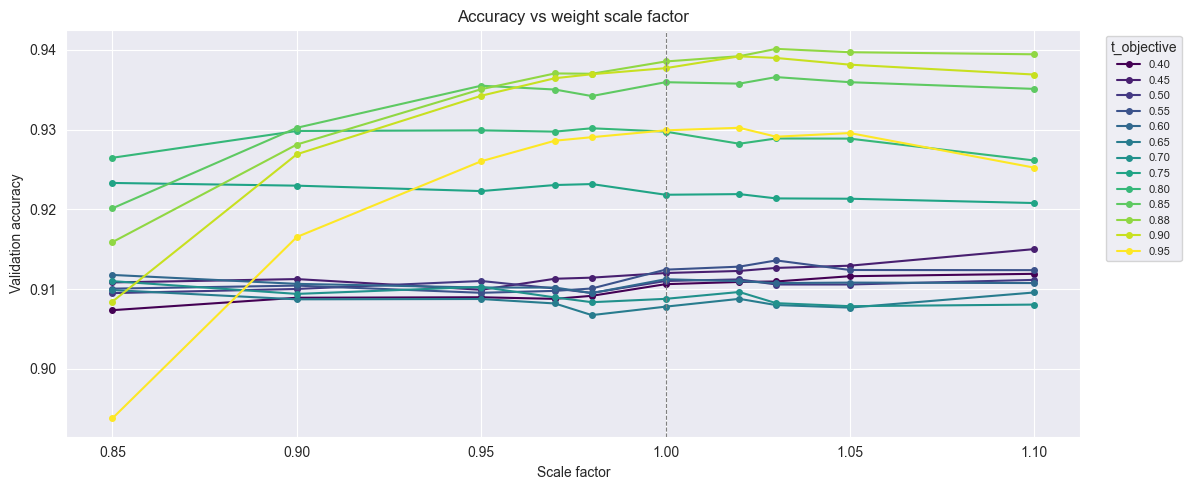

In [48]:
# Plot 5: Absolute accuracy vs scale factor (one line per t_objective)
all_factors = [1.0] + scale_factors
cmap = plt.cm.viridis(np.linspace(0, 1, len(scaling)))

fig, ax = plt.subplots(figsize=(12, 5))
for (tobj, seed_results), color in zip(scaling.items(), cmap):
    baselines = [r["baseline"]["accuracy"] for r in seed_results]
    factor_accs = {
        f: [r["factors"][str(f)]["accuracy"] for r in seed_results]
        for f in scale_factors
    }
    means = {1.0: np.mean(baselines)}
    means.update({f: np.mean(accs) for f, accs in factor_accs.items()})
    xs = sorted(means)
    ys = [means[x] for x in xs]
    ax.plot(xs, ys, "o-", color=color, label=f"{tobj:.2f}", markersize=4)

ax.set_xlabel("Scale factor")
ax.set_ylabel("Validation accuracy")
ax.set_title("Accuracy vs weight scale factor")
ax.legend(title="t_objective", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

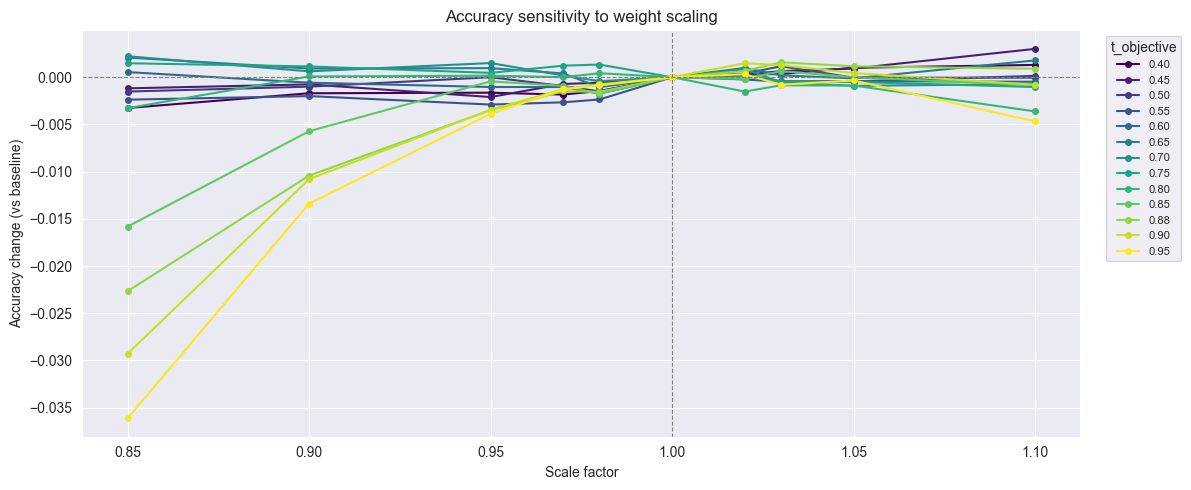

In [49]:
# Plot 6: Accuracy drop relative to baseline (sensitivity)
fig, ax = plt.subplots(figsize=(12, 5))
for (tobj, seed_results), color in zip(scaling.items(), cmap):
    baselines = [r["baseline"]["accuracy"] for r in seed_results]
    mean_baseline = np.mean(baselines)
    factor_accs = {
        f: [r["factors"][str(f)]["accuracy"] for r in seed_results]
        for f in scale_factors
    }
    deltas = {1.0: 0.0}
    deltas.update({f: np.mean(accs) - mean_baseline for f, accs in factor_accs.items()})
    xs = sorted(deltas)
    ys = [deltas[x] for x in xs]
    ax.plot(xs, ys, "o-", color=color, label=f"{tobj:.2f}", markersize=4)

ax.set_xlabel("Scale factor")
ax.set_ylabel("Accuracy change (vs baseline)")
ax.set_title("Accuracy sensitivity to weight scaling")
ax.legend(title="t_objective", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

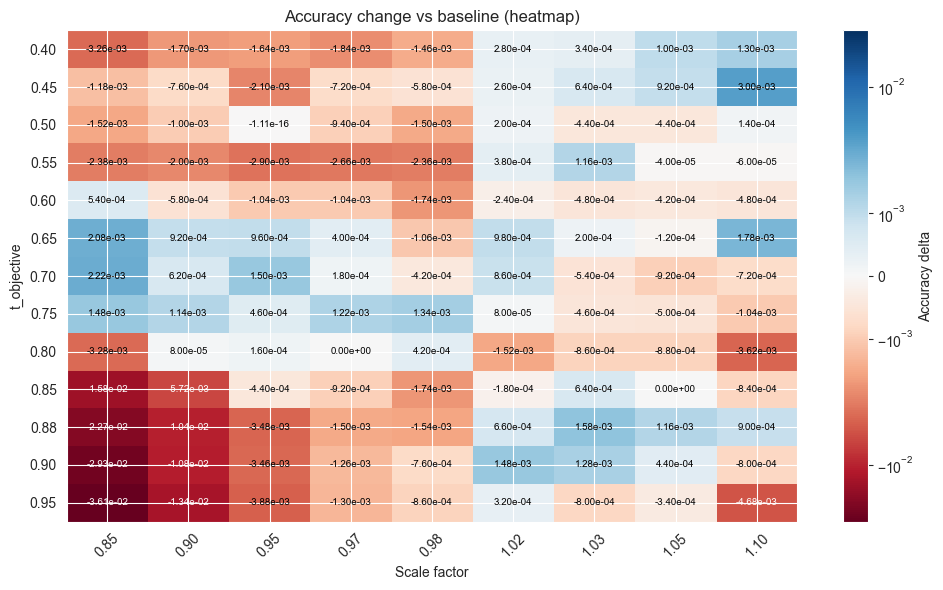

In [50]:
# Plot 7: Heatmap of accuracy delta (t_objective x scale factor)
from matplotlib.colors import SymLogNorm

t_objs_with_scaling = sorted(scaling.keys())
delta_matrix = np.zeros((len(t_objs_with_scaling), len(scale_factors)))

for i, tobj in enumerate(t_objs_with_scaling):
    seed_results = scaling[tobj]
    mean_baseline = np.mean([r["baseline"]["accuracy"] for r in seed_results])
    for j, f in enumerate(scale_factors):
        mean_acc = np.mean([r["factors"][str(f)]["accuracy"] for r in seed_results])
        delta_matrix[i, j] = mean_acc - mean_baseline

vmax = np.abs(delta_matrix).max()
norm = SymLogNorm(linthresh=vmax * 0.05, vmin=-vmax, vmax=vmax)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(delta_matrix, aspect="auto", cmap="RdBu", norm=norm)
for i in range(len(t_objs_with_scaling)):
    for j in range(len(scale_factors)):
        val = delta_matrix[i, j]
        color = "white" if abs(norm(val) - 0.5) > 0.3 else "black"
        ax.text(j, i, f"{val:.2e}", ha="center", va="center", fontsize=7, color=color)
ax.set_xticks(range(len(scale_factors)))
ax.set_xticklabels([f"{f:.2f}" for f in scale_factors], rotation=45)
ax.set_yticks(range(len(t_objs_with_scaling)))
ax.set_yticklabels([f"{t:.2f}" for t in t_objs_with_scaling])
ax.set_xlabel("Scale factor")
ax.set_ylabel("t_objective")
ax.set_title("Accuracy change vs baseline (heatmap)")
fig.colorbar(im, ax=ax, label="Accuracy delta")
plt.tight_layout()
plt.show()

# Weight-threshold relationship
How do learned weight sums relate to thresholds across t_objectives?

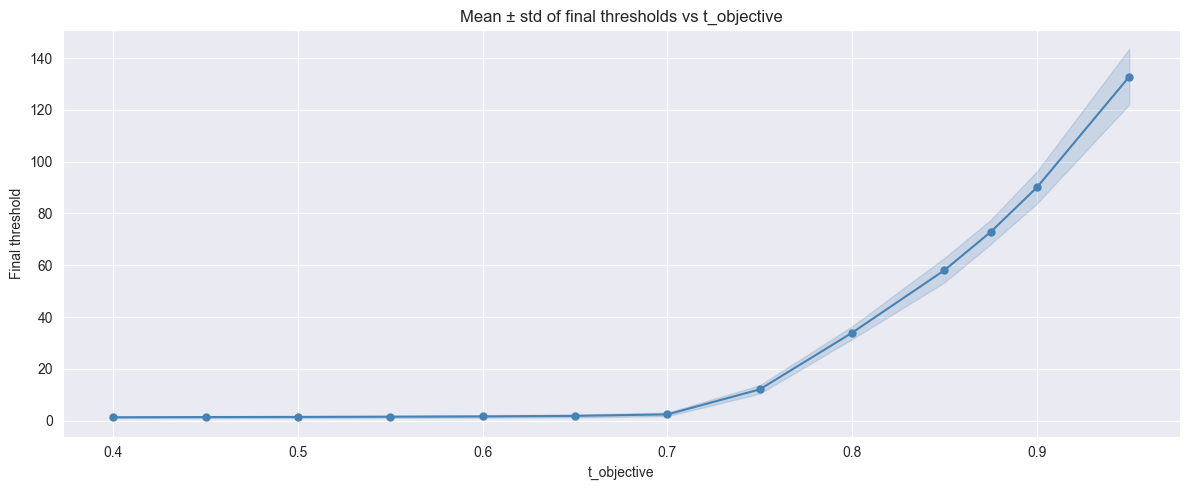

In [51]:
# Mean ± std of final thresholds vs t_objective
means = [np.mean(training[t]["threshold_final"]) for t in t_objectives]
stds = [np.std(training[t]["threshold_final"]) for t in t_objectives]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_objectives, means, "o-", color="steelblue", markersize=5)
ax.fill_between(t_objectives, np.array(means) - np.array(stds),
                np.array(means) + np.array(stds), alpha=0.2, color="steelblue")
ax.set_xlabel("t_objective")
ax.set_ylabel("Final threshold")
ax.set_title("Mean ± std of final thresholds vs t_objective")
plt.tight_layout()
plt.show()

In [52]:
# Load weight sums and thresholds from saved models
import torch
from spiking import load_model

weight_sums_by_tobj = {}
thresholds_by_tobj = {}
ratios_by_tobj = {}
top_half_wsums_by_tobj = {}
for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    all_wsums, all_thresholds, all_ratios, all_top_half = [], [], [], []
    for seed_dir in seed_dirs:
        model_path = os.path.join(tobj_path, seed_dir, "model.pth")
        if not os.path.exists(model_path):
            continue
        model = load_model(model_path)
        layer = model.layers[0]
        weights = layer.weights.detach()
        thresholds = layer.thresholds.detach()
        wsums = weights.sum(dim=1).cpu().numpy()
        threshs = thresholds.cpu().numpy()
        # Top-half: sum of largest N/2 weights per neuron
        n_inputs = weights.shape[1]
        sorted_w, _ = weights.sort(dim=1, descending=True)
        top_half = sorted_w[:, :n_inputs // 2].sum(dim=1).cpu().numpy()
        all_wsums.extend(wsums.tolist())
        all_thresholds.extend(threshs.tolist())
        all_ratios.extend((wsums / threshs).tolist())
        all_top_half.extend(top_half.tolist())
    weight_sums_by_tobj[tobj] = all_wsums
    thresholds_by_tobj[tobj] = all_thresholds
    ratios_by_tobj[tobj] = all_ratios
    top_half_wsums_by_tobj[tobj] = all_top_half

print(f"Loaded {len(ratios_by_tobj)} t_objectives")
print(f"Neurons per t_objective: {len(ratios_by_tobj[t_objectives[0]])}")
print(f"Input neurons: {n_inputs}, top-half count: {n_inputs // 2}")

Loaded 13 t_objectives
Neurons per t_objective: 1280
Input neurons: 1568, top-half count: 784


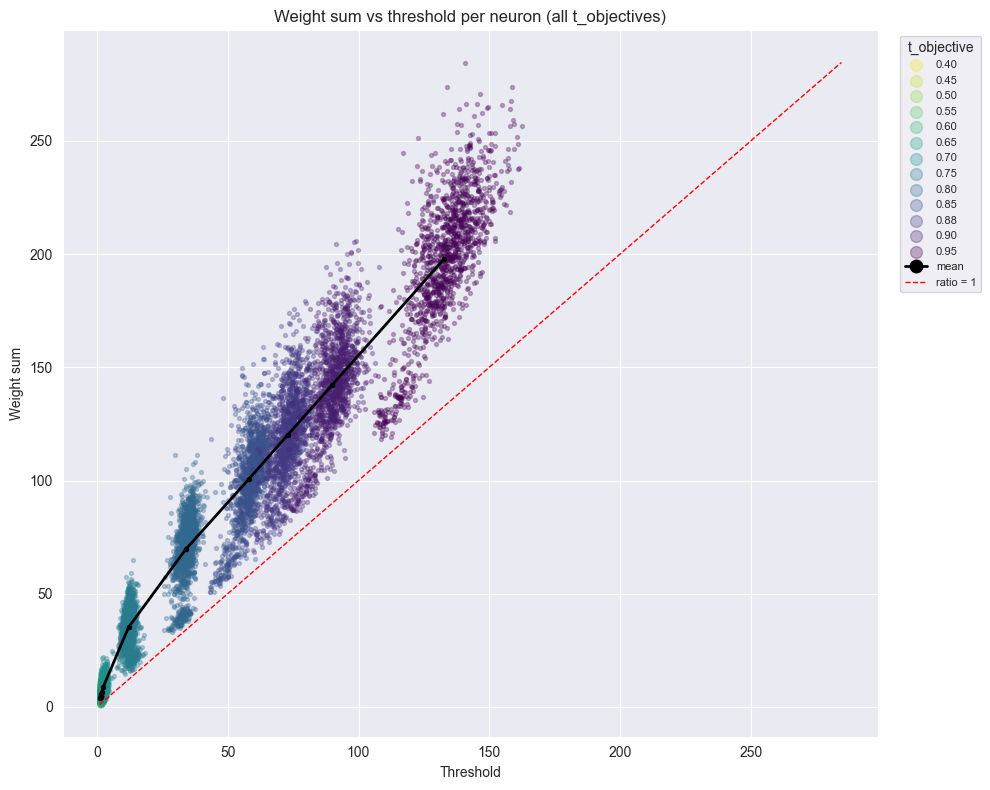

In [53]:
# Weight sum vs threshold scatter (per neuron, colored by t_objective)
fig, ax = plt.subplots(figsize=(10, 8))
cmap_colors = plt.cm.viridis_r(np.linspace(0, 1, len(t_objectives)))
for tobj, color in zip(t_objectives, cmap_colors):
    ax.scatter(thresholds_by_tobj[tobj], weight_sums_by_tobj[tobj],
               c=[color], s=8, alpha=0.3, label=f"{tobj:.2f}")

# Line connecting mean weight sum per t_objective
mean_thresholds = [np.mean(thresholds_by_tobj[t]) for t in t_objectives]
mean_wsums = [np.mean(weight_sums_by_tobj[t]) for t in t_objectives]
ax.plot(mean_thresholds, mean_wsums, "o-", color="black", markersize=3,
        linewidth=2, label="mean", zorder=5)

# Identity line (ratio = 1)
all_vals = [v for t in t_objectives for v in thresholds_by_tobj[t] + weight_sums_by_tobj[t]]
lim = [min(all_vals), max(all_vals)]
ax.plot(lim, lim, "--", color="red", linewidth=1, label="ratio = 1")

ax.set_xlabel("Threshold")
ax.set_ylabel("Weight sum")
ax.set_title("Weight sum vs threshold per neuron (all t_objectives)")
ax.legend(title="t_objective", bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

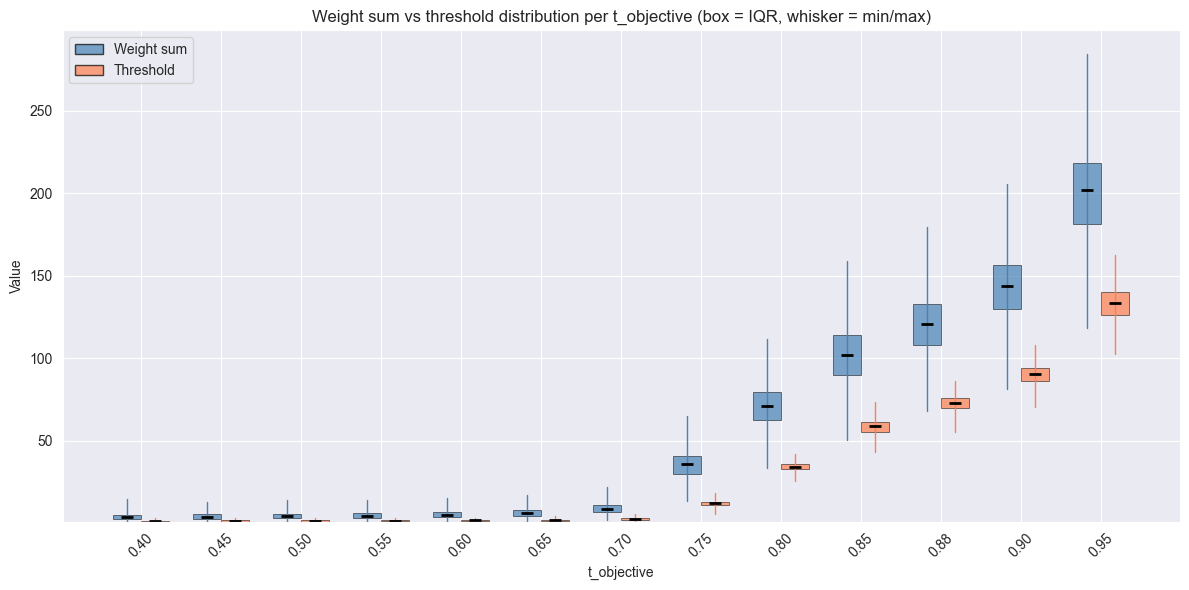

In [54]:
# Candlestick-style plot: weight sum and threshold ranges per t_objective
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(t_objectives))
width = 0.35

for i, tobj in enumerate(t_objectives):
    ws = np.array(weight_sums_by_tobj[tobj])
    th = np.array(thresholds_by_tobj[tobj])
    # Weight sum candle (left)
    ws_q1, ws_med, ws_q3 = np.percentile(ws, [25, 50, 75])
    ax.bar(i - width/2, ws_q3 - ws_q1, bottom=ws_q1, width=width,
           color="steelblue", alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.plot([i - width/2, i - width/2], [ws.min(), ws.max()],
            color="steelblue", linewidth=1)
    ax.plot(i - width/2, ws_med, "_", color="black", markersize=8, markeredgewidth=2)
    # Threshold candle (right)
    th_q1, th_med, th_q3 = np.percentile(th, [25, 50, 75])
    ax.bar(i + width/2, th_q3 - th_q1, bottom=th_q1, width=width,
           color="coral", alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.plot([i + width/2, i + width/2], [th.min(), th.max()],
            color="coral", linewidth=1)
    ax.plot(i + width/2, th_med, "_", color="black", markersize=8, markeredgewidth=2)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in t_objectives], rotation=45)
ax.set_xlabel("t_objective")
ax.set_ylabel("Value")
ax.set_title("Weight sum vs threshold distribution per t_objective (box = IQR, whisker = min/max)")
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, fc="steelblue", alpha=0.7, ec="black"),
    plt.Rectangle((0, 0), 1, 1, fc="coral", alpha=0.7, ec="black"),
], labels=["Weight sum", "Threshold"])
plt.tight_layout()
plt.show()

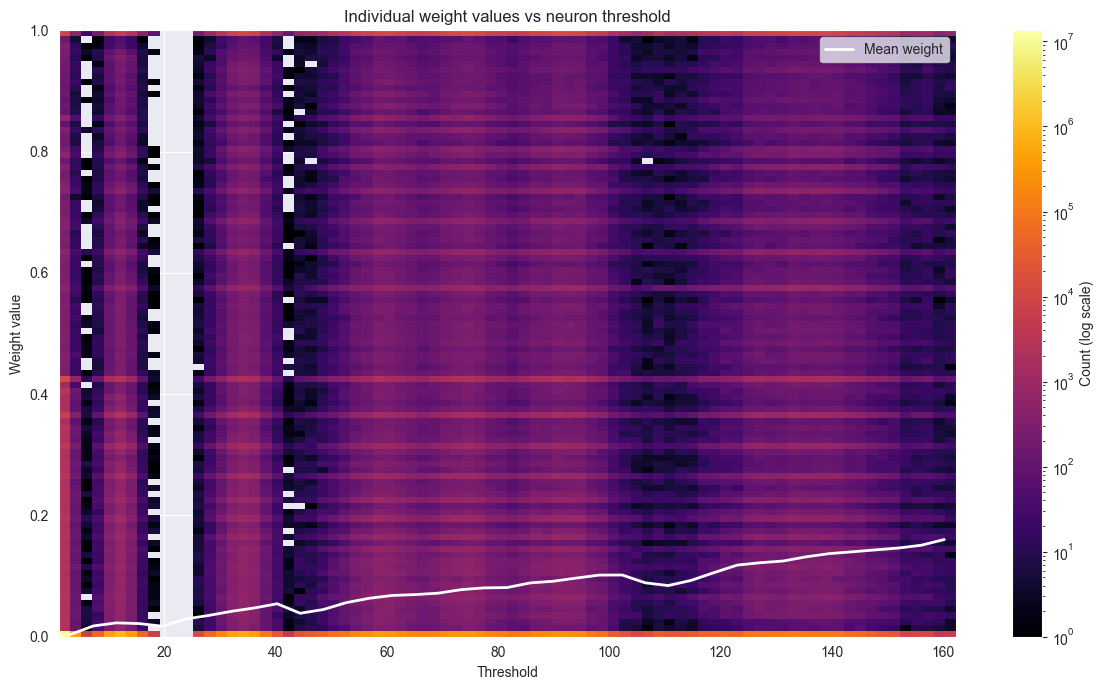

Total (threshold, weight) pairs: 26,091,520


In [55]:
# Weight distribution vs threshold: 2D density
# Each neuron contributes (threshold, weight_i) for all its input weights
all_thresh_repeated = []
all_weight_vals = []
for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    for seed_dir in seed_dirs:
        model_path = os.path.join(tobj_path, seed_dir, "model.pth")
        if not os.path.exists(model_path):
            continue
        model = load_model(model_path)
        layer = model.layers[0]
        weights = layer.weights.detach().cpu().numpy()  # (n_neurons, n_inputs)
        thresholds = layer.thresholds.detach().cpu().numpy()  # (n_neurons,)
        for neuron_idx in range(weights.shape[0]):
            all_thresh_repeated.extend([thresholds[neuron_idx]] * weights.shape[1])
            all_weight_vals.extend(weights[neuron_idx].tolist())

all_thresh_repeated = np.array(all_thresh_repeated)
all_weight_vals = np.array(all_weight_vals)

fig, ax = plt.subplots(figsize=(12, 7))
h = ax.hist2d(all_thresh_repeated, all_weight_vals, bins=[80, 100],
              cmap="inferno", norm=plt.matplotlib.colors.LogNorm())
fig.colorbar(h[3], ax=ax, label="Count (log scale)")

# Overlay mean weight per threshold bin
thresh_bins = np.linspace(all_thresh_repeated.min(), all_thresh_repeated.max(), 40)
bin_indices = np.digitize(all_thresh_repeated, thresh_bins)
mean_weights = [all_weight_vals[bin_indices == i].mean()
                for i in range(1, len(thresh_bins))
                if (bin_indices == i).sum() > 0]
valid_centers = [(thresh_bins[i-1] + thresh_bins[i]) / 2
                 for i in range(1, len(thresh_bins))
                 if (bin_indices == i).sum() > 0]
ax.plot(valid_centers, mean_weights, "w-", linewidth=2, label="Mean weight")

ax.set_xlabel("Threshold")
ax.set_ylabel("Weight value")
ax.set_title("Individual weight values vs neuron threshold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Total (threshold, weight) pairs: {len(all_thresh_repeated):,}")

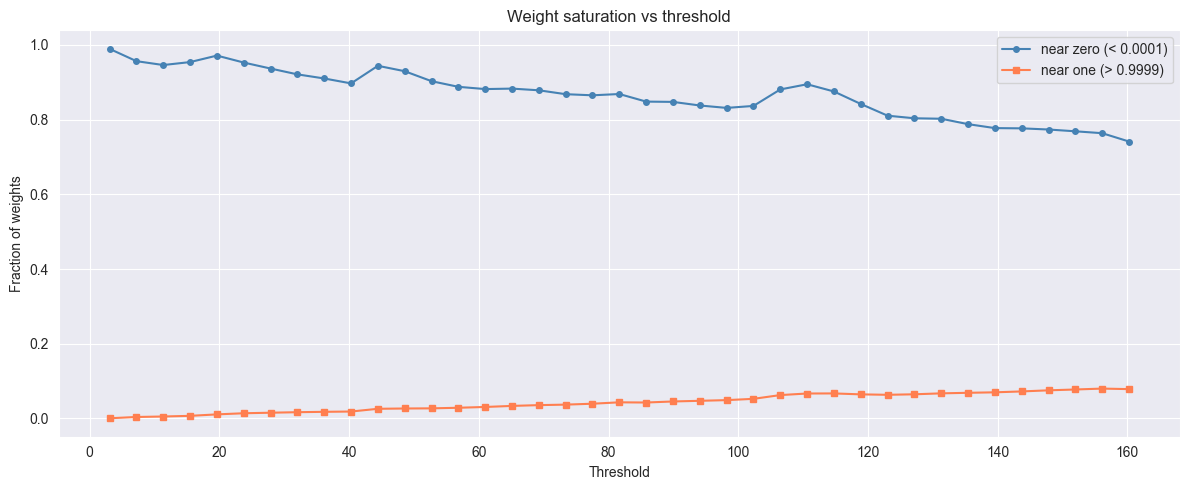

In [56]:
# Fraction of near-zero and near-one weights vs threshold
eps = 1e-4
thresh_bins = np.linspace(all_thresh_repeated.min(), all_thresh_repeated.max(), 40)
bin_indices = np.digitize(all_thresh_repeated, thresh_bins)

centers, frac_near_zero, frac_near_one = [], [], []
for i in range(1, len(thresh_bins)):
    mask = bin_indices == i
    if mask.sum() == 0:
        continue
    w = all_weight_vals[mask]
    centers.append((thresh_bins[i-1] + thresh_bins[i]) / 2)
    frac_near_zero.append((w < eps).mean())
    frac_near_one.append((w > 1 - eps).mean())

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(centers, frac_near_zero, "o-", color="steelblue", markersize=4, label=f"near zero (< {eps})")
ax.plot(centers, frac_near_one, "s-", color="coral", markersize=4, label=f"near one (> {1-eps})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Fraction of weights")
ax.set_title("Weight saturation vs threshold")
ax.legend()
plt.tight_layout()
plt.show()

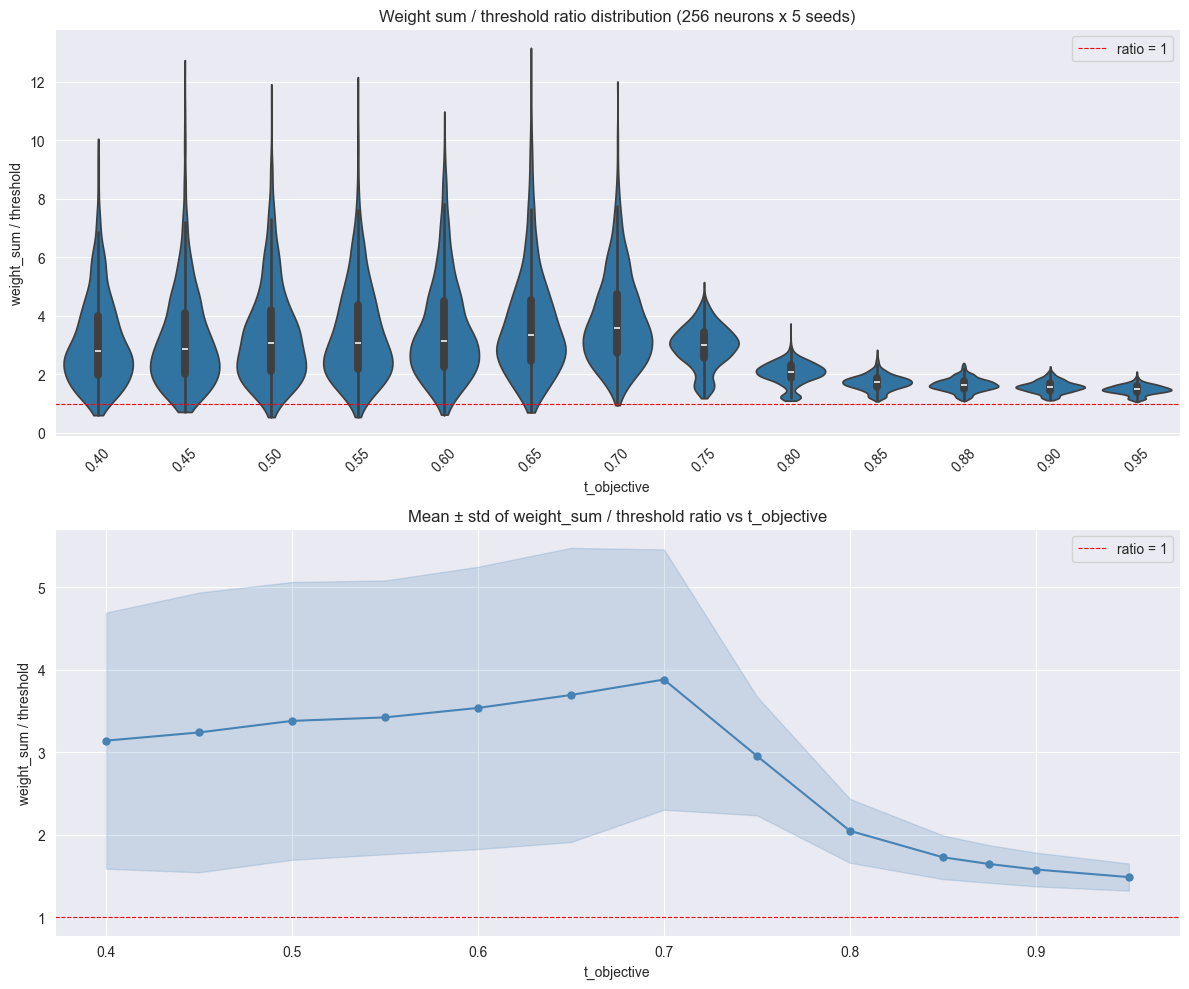

In [57]:
# Violin plot of weight_sum/threshold ratio + mean±std line plot
ratio_data = []
ratio_labels = []
for t in t_objectives:
    if t not in ratios_by_tobj:
        continue
    ratio_data.extend(ratios_by_tobj[t])
    ratio_labels.extend([f"{t:.2f}"] * len(ratios_by_tobj[t]))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Violin plot
ax = axes[0]
sns.violinplot(x=ratio_labels, y=ratio_data, ax=ax, inner="box", cut=0, density_norm="width")
ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="ratio = 1")
ax.set_xlabel("t_objective")
ax.set_ylabel("weight_sum / threshold")
ax.set_title("Weight sum / threshold ratio distribution (256 neurons x 5 seeds)")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45)

# Mean ± std line plot
ax = axes[1]
t_with_ratios = [t for t in t_objectives if t in ratios_by_tobj]
ratio_means = [np.mean(ratios_by_tobj[t]) for t in t_with_ratios]
ratio_stds = [np.std(ratios_by_tobj[t]) for t in t_with_ratios]
ax.plot(t_with_ratios, ratio_means, "o-", color="steelblue", markersize=5)
ax.fill_between(t_with_ratios, np.array(ratio_means) - np.array(ratio_stds),
                np.array(ratio_means) + np.array(ratio_stds), alpha=0.2, color="steelblue")
ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="ratio = 1")
ax.set_xlabel("t_objective")
ax.set_ylabel("weight_sum / threshold")
ax.set_title("Mean ± std of weight_sum / threshold ratio vs t_objective")
ax.legend()

plt.tight_layout()
plt.show()

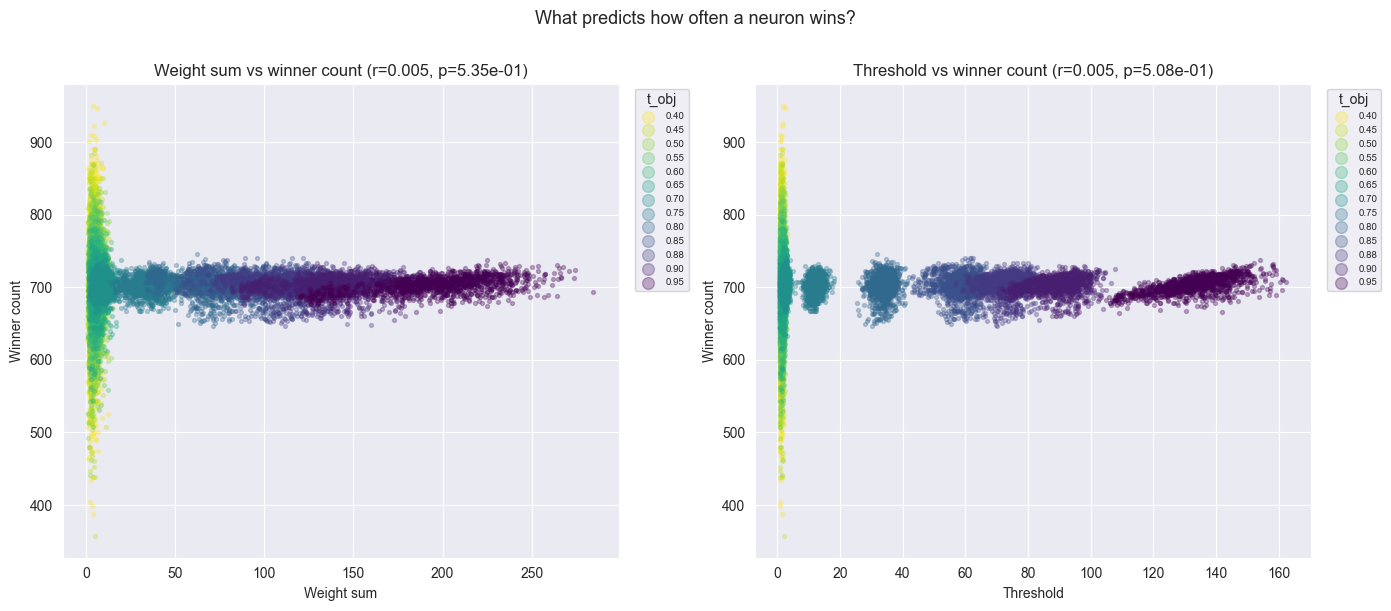

In [58]:
# Weight sum vs winner count correlation (per neuron, colored by t_objective)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap_colors = plt.cm.viridis_r(np.linspace(0, 1, len(t_objectives)))

# Left: weight sum vs winner count
ax = axes[0]
all_wsums_flat, all_winners_flat, all_tobjs_flat = [], [], []
for tobj, color in zip(t_objectives, cmap_colors):
    wsums = weight_sums_by_tobj[tobj]
    winners = training[tobj]["winner_counts"]
    ax.scatter(wsums, winners, c=[color], s=8, alpha=0.3, label=f"{tobj:.2f}")
    all_wsums_flat.extend(wsums)
    all_winners_flat.extend(winners)
    all_tobjs_flat.extend([tobj] * len(wsums))
r, p = stats.pearsonr(all_wsums_flat, all_winners_flat)
ax.set_xlabel("Weight sum")
ax.set_ylabel("Winner count")
ax.set_title(f"Weight sum vs winner count (r={r:.3f}, p={p:.2e})")

# Right: threshold vs winner count
ax = axes[1]
all_thresh_flat, all_winners_flat2 = [], []
for tobj, color in zip(t_objectives, cmap_colors):
    threshs = thresholds_by_tobj[tobj]
    winners = training[tobj]["winner_counts"]
    ax.scatter(threshs, winners, c=[color], s=8, alpha=0.3, label=f"{tobj:.2f}")
    all_thresh_flat.extend(threshs)
    all_winners_flat2.extend(winners)
r2, p2 = stats.pearsonr(all_thresh_flat, all_winners_flat2)
ax.set_xlabel("Threshold")
ax.set_ylabel("Winner count")
ax.set_title(f"Threshold vs winner count (r={r2:.3f}, p={p2:.2e})")

for ax in axes:
    ax.legend(title="t_obj", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, markerscale=3)
fig.suptitle("What predicts how often a neuron wins?", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

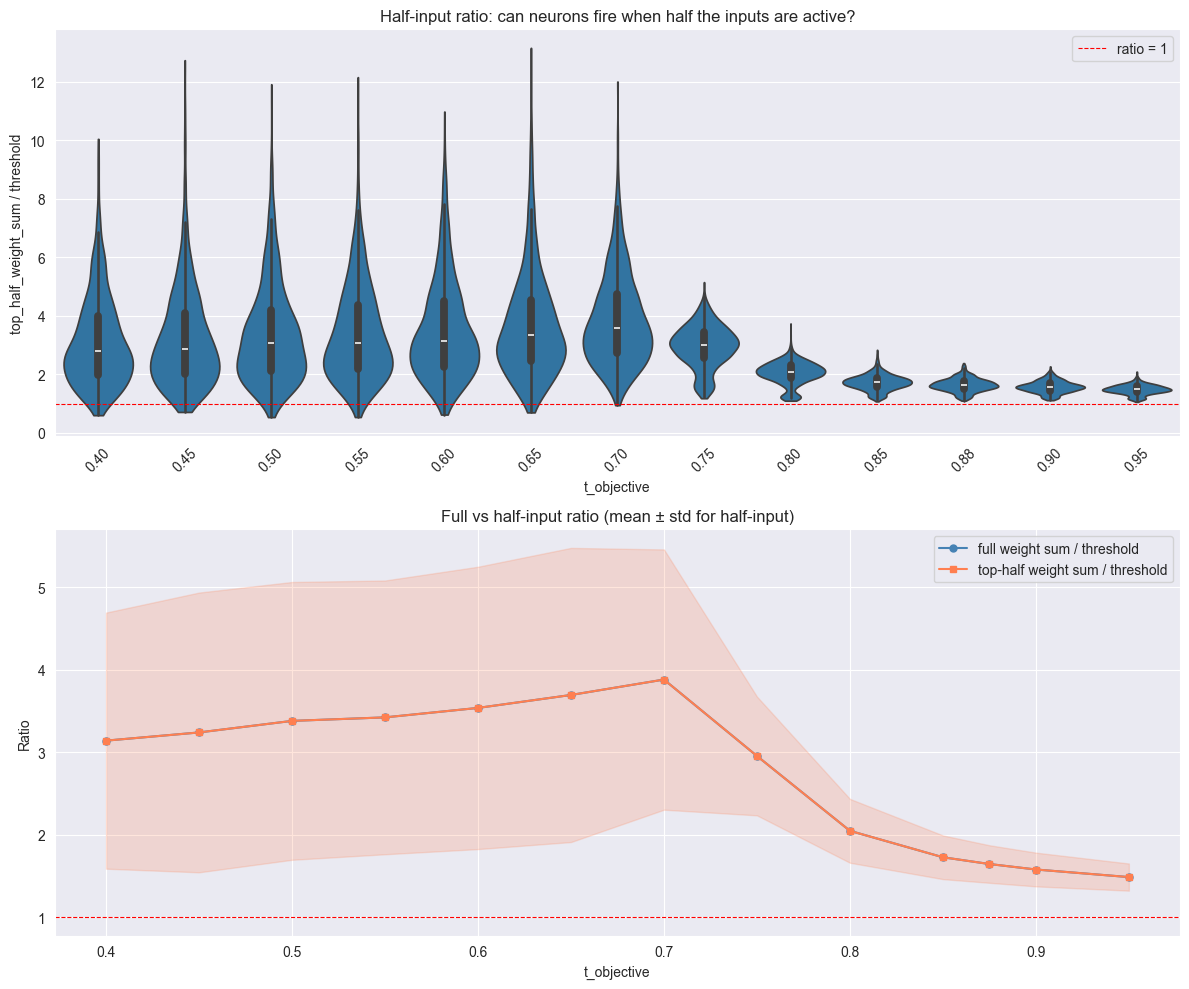

In [59]:
# Half-input ratio: top_half_weight_sum / threshold
# Assumes half the input neurons fire — more realistic than full weight sum
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Violin plot
ax = axes[0]
half_ratio_data, half_ratio_labels = [], []
for t in t_objectives:
    half_ratios = [ws / th for ws, th in zip(top_half_wsums_by_tobj[t], thresholds_by_tobj[t])]
    half_ratio_data.extend(half_ratios)
    half_ratio_labels.extend([f"{t:.2f}"] * len(half_ratios))
sns.violinplot(x=half_ratio_labels, y=half_ratio_data, ax=ax, inner="box", cut=0, density_norm="width")
ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, label="ratio = 1")
ax.set_xlabel("t_objective")
ax.set_ylabel("top_half_weight_sum / threshold")
ax.set_title("Half-input ratio: can neurons fire when half the inputs are active?")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45)

# Mean ± std line: full ratio vs half-input ratio
ax = axes[1]
full_means = [np.mean(ratios_by_tobj[t]) for t in t_objectives]
half_means = [np.mean([ws / th for ws, th in zip(top_half_wsums_by_tobj[t], thresholds_by_tobj[t])])
              for t in t_objectives]
half_stds = [np.std([ws / th for ws, th in zip(top_half_wsums_by_tobj[t], thresholds_by_tobj[t])])
             for t in t_objectives]
ax.plot(t_objectives, full_means, "o-", color="steelblue", markersize=5, label="full weight sum / threshold")
ax.plot(t_objectives, half_means, "s-", color="coral", markersize=5, label="top-half weight sum / threshold")
ax.fill_between(t_objectives, np.array(half_means) - np.array(half_stds),
                np.array(half_means) + np.array(half_stds), alpha=0.2, color="coral")
ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("t_objective")
ax.set_ylabel("Ratio")
ax.set_title("Full vs half-input ratio (mean ± std for half-input)")
ax.legend()

plt.tight_layout()
plt.show()

# Experiment 3: Per-neuron threshold perturbation

Each neuron's threshold is individually perturbed by 31 fractions (-0.5 to +0.25, step 0.025) while all other neurons keep their trained thresholds. A classifier is retrained for each (neuron, fraction) pair to measure per-neuron accuracy impact. Per-neuron optimal thresholds are found by accuracy argmax across fractions. 256 neurons × 31 fractions, 2 seeds per t_objective.

In [60]:
# Load perturbation_results.json and optimal_thresholds.json per seed per t_objective
perturbation = {}
optimal = {}
for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    perturb_seeds = []
    optimal_seeds = []
    for seed_dir in seed_dirs:
        seed_path = os.path.join(tobj_path, seed_dir)
        pr_path = os.path.join(seed_path, "perturbation_results.json")
        ot_path = os.path.join(seed_path, "optimal_thresholds.json")
        if os.path.exists(pr_path):
            with open(pr_path) as f:
                perturb_seeds.append(json.load(f))
        if os.path.exists(ot_path):
            with open(ot_path) as f:
                optimal_seeds.append(json.load(f))
    if perturb_seeds:
        perturbation[tobj] = perturb_seeds
    if optimal_seeds:
        optimal[tobj] = optimal_seeds

print(f"Loaded perturbation results for {len(perturbation)}/{len(t_objectives)} t_objectives")
print(f"Loaded optimal thresholds for {len(optimal)}/{len(t_objectives)} t_objectives")
for t in sorted(perturbation):
    print(f"  t_obj={t:.3f}: {len(perturbation[t])} seeds (perturbation), {len(optimal.get(t, []))} seeds (optimal)")

Loaded perturbation results for 13/13 t_objectives
Loaded optimal thresholds for 13/13 t_objectives
  t_obj=0.400: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.450: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.500: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.550: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.600: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.650: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.700: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.750: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.800: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.850: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.875: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.900: 2 seeds (perturbation), 2 seeds (optimal)
  t_obj=0.950: 2 seeds (perturbation), 2 seeds (optimal)


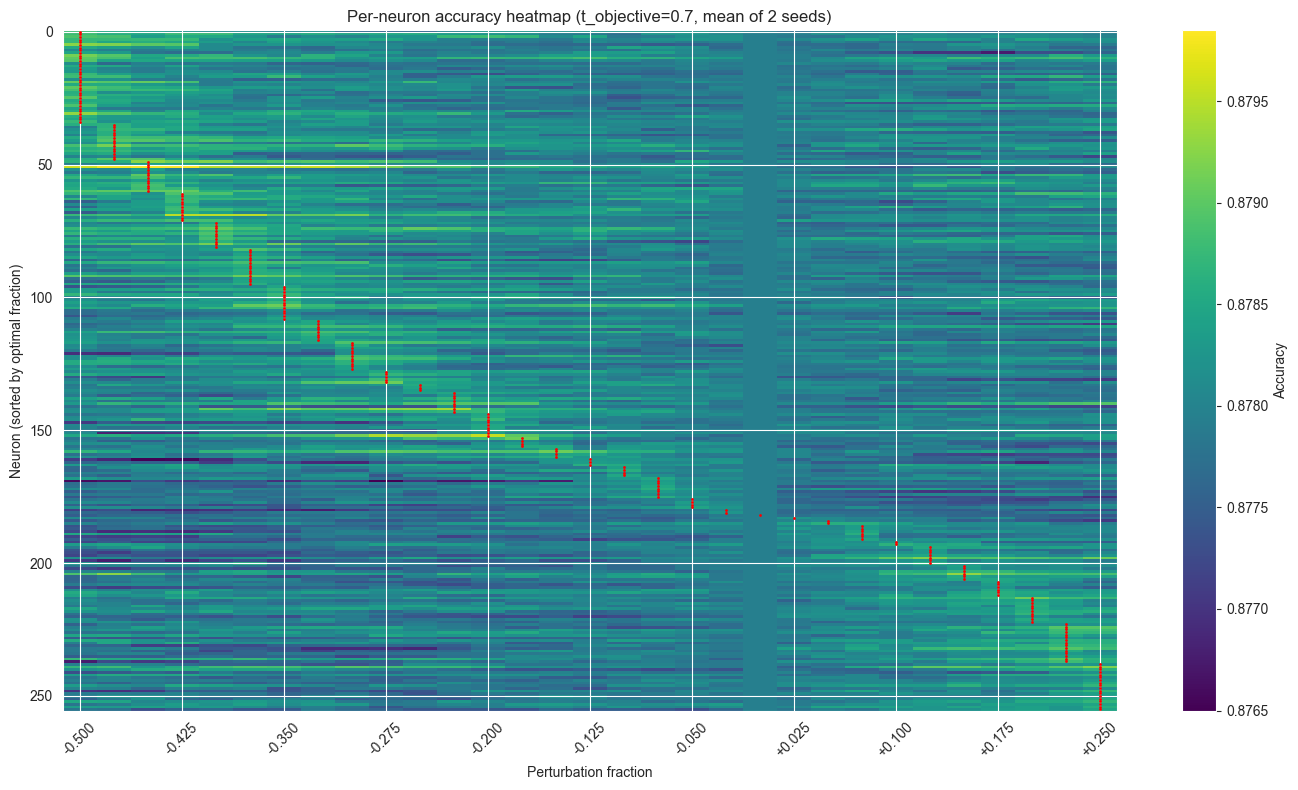

In [61]:
# Plot 8: Accuracy heatmap for a representative t_objective (median accuracy)
# Pick the t_objective with median baseline accuracy
p_tobjs = sorted(perturbation.keys())
median_accs = [(t, np.mean([s["baseline"]["accuracy"] for s in perturbation[t]])) for t in p_tobjs]
median_accs.sort(key=lambda x: x[1])
rep_tobj = median_accs[len(median_accs) // 2][0]

# Average accuracy_matrix across seeds
acc_matrices = [np.array(s["accuracy_matrix"]) for s in perturbation[rep_tobj]]
mean_acc = np.mean(acc_matrices, axis=0)  # (256, 31)
fractions = perturbation[rep_tobj][0]["perturbation_fractions"]

# Sort neurons by their optimal fraction for visual clarity
best_frac_idx = mean_acc.argmax(axis=1)
sort_order = np.argsort(best_frac_idx)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(mean_acc[sort_order], aspect="auto", cmap="viridis",
               interpolation="nearest")
# Highlight argmax per neuron
for row, neuron_idx in enumerate(sort_order):
    ax.plot(best_frac_idx[neuron_idx], row, "r.", markersize=2)

ax.set_xticks(range(0, len(fractions), 3))
ax.set_xticklabels([f"{fractions[i]:+.3f}" for i in range(0, len(fractions), 3)], rotation=45)
ax.set_xlabel("Perturbation fraction")
ax.set_ylabel("Neuron (sorted by optimal fraction)")
ax.set_title(f"Per-neuron accuracy heatmap (t_objective={rep_tobj}, mean of {len(acc_matrices)} seeds)")
fig.colorbar(im, ax=ax, label="Accuracy")
plt.tight_layout()
plt.show()

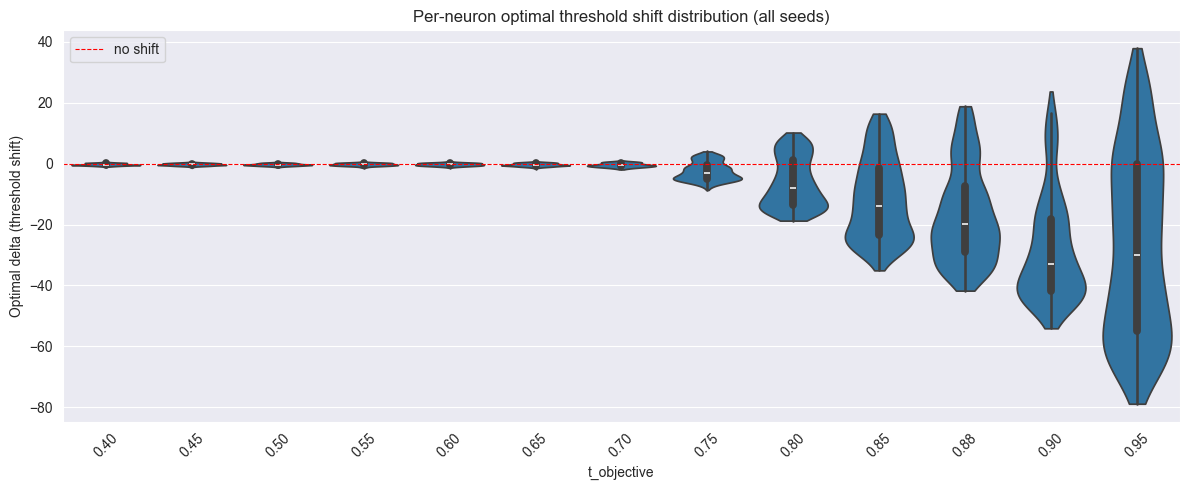

In [62]:
# Plot 9: Optimal delta distribution across t_objectives (violin plot)
delta_data = []
delta_labels = []
for t in p_tobjs:
    for seed_result in perturbation[t]:
        deltas = seed_result["optimal_deltas"]
        delta_data.extend(deltas)
        delta_labels.extend([f"{t:.2f}"] * len(deltas))

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(x=delta_labels, y=delta_data, ax=ax,
               inner="box", cut=0, density_norm="width")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="no shift")
ax.set_xlabel("t_objective")
ax.set_ylabel("Optimal delta (threshold shift)")
ax.set_title("Per-neuron optimal threshold shift distribution (all seeds)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

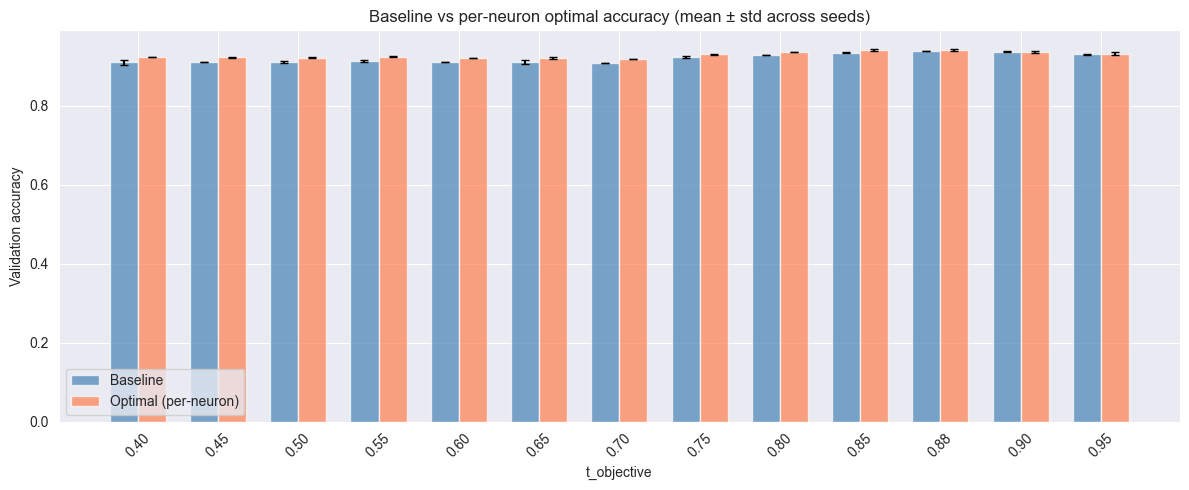

  t_obj=0.40: baseline=0.9103 optimal=0.9241 improvement=+0.0138
  t_obj=0.45: baseline=0.9114 optimal=0.9224 improvement=+0.0110
  t_obj=0.50: baseline=0.9110 optimal=0.9221 improvement=+0.0111
  t_obj=0.55: baseline=0.9140 optimal=0.9249 improvement=+0.0109
  t_obj=0.60: baseline=0.9111 optimal=0.9214 improvement=+0.0103
  t_obj=0.65: baseline=0.9109 optimal=0.9217 improvement=+0.0108
  t_obj=0.70: baseline=0.9096 optimal=0.9190 improvement=+0.0094
  t_obj=0.75: baseline=0.9230 optimal=0.9306 improvement=+0.0076
  t_obj=0.80: baseline=0.9287 optimal=0.9366 improvement=+0.0080
  t_obj=0.85: baseline=0.9342 optimal=0.9410 improvement=+0.0068
  t_obj=0.88: baseline=0.9388 optimal=0.9415 improvement=+0.0027
  t_obj=0.90: baseline=0.9373 optimal=0.9355 improvement=-0.0018
  t_obj=0.95: baseline=0.9301 optimal=0.9321 improvement=+0.0020


In [63]:
# Plot 10: Accuracy improvement — baseline vs optimal-combined per t_objective
o_tobjs = sorted(optimal.keys())
baseline_means = [np.mean([s["baseline"]["accuracy"] for s in optimal[t]]) for t in o_tobjs]
baseline_stds = [np.std([s["baseline"]["accuracy"] for s in optimal[t]]) for t in o_tobjs]
optimal_means = [np.mean([s["optimal_combined"]["accuracy"] for s in optimal[t]]) for t in o_tobjs]
optimal_stds = [np.std([s["optimal_combined"]["accuracy"] for s in optimal[t]]) for t in o_tobjs]

x = np.arange(len(o_tobjs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, baseline_means, width, yerr=baseline_stds, capsize=3,
       label="Baseline", color="steelblue", alpha=0.7)
ax.bar(x + width / 2, optimal_means, width, yerr=optimal_stds, capsize=3,
       label="Optimal (per-neuron)", color="coral", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in o_tobjs], rotation=45)
ax.set_xlabel("t_objective")
ax.set_ylabel("Validation accuracy")
ax.set_title("Baseline vs per-neuron optimal accuracy (mean ± std across seeds)")
ax.legend()
plt.tight_layout()
plt.show()

# Print improvements
for t, bm, om in zip(o_tobjs, baseline_means, optimal_means):
    print(f"  t_obj={t:.2f}: baseline={bm:.4f} optimal={om:.4f} improvement={om - bm:+.4f}")

In [64]:
# Correlation summary: Pearson r between original_thresholds and optimal_deltas per t_objective
from applications.threshold_research.analysis import correlations_report

print(f"{'t_objective':>11} | {'r (thresh→delta)':>16} | {'p-value':>10} | {'n_increase':>10} | {'n_decrease':>10} | {'n_same':>6}")
print("-" * 80)
for t in p_tobjs:
    # Concatenate across seeds for this t_objective
    all_originals = []
    all_deltas = []
    for seed_result in perturbation[t]:
        all_originals.extend(seed_result["original_thresholds"])
        all_deltas.extend(seed_result["optimal_deltas"])
    r, p = stats.pearsonr(all_originals, all_deltas)
    deltas_arr = np.array(all_deltas)
    n_inc = np.sum(deltas_arr > 0)
    n_dec = np.sum(deltas_arr < 0)
    n_same = np.sum(deltas_arr == 0)
    p_str = f"{p:.2e}" if p < 0.001 else f"{p:.4f}"
    print(f"{t:11.2f} | {r:16.4f} | {p_str:>10} | {n_inc:10d} | {n_dec:10d} | {n_same:6d}")

# Full correlations_report for the representative t_objective
print(f"\nFull correlation report for representative t_objective={rep_tobj}:")
rep_results = perturbation[rep_tobj][0]  # first seed
report = correlations_report(rep_results)
for key, val in report.items():
    if "r" in val:
        print(f"  {val['description']}: r={val['r']:.4f}, p={val['p']:.2e}")
    elif "increase" in val:
        print(f"  {val['description']}: +{val['increase']} / -{val['decrease']} / ={val['same']}")

t_objective | r (thresh→delta) |    p-value | n_increase | n_decrease | n_same
--------------------------------------------------------------------------------
       0.40 |          -0.1617 |   2.38e-04 |        151 |        361 |      0
       0.45 |          -0.1608 |   2.58e-04 |        133 |        355 |     24
       0.50 |          -0.2524 |   6.95e-09 |        113 |        385 |     14
       0.55 |          -0.2124 |   1.23e-06 |        151 |        356 |      5
       0.60 |          -0.1375 |     0.0018 |        149 |        340 |     23
       0.65 |          -0.2476 |   1.38e-08 |        134 |        368 |     10
       0.70 |          -0.1169 |     0.0081 |        133 |        372 |      7
       0.75 |          -0.1532 |   5.05e-04 |        117 |        395 |      0
       0.80 |          -0.0034 |     0.9380 |        138 |        367 |      7
       0.85 |           0.0261 |     0.5563 |        103 |        397 |     12
       0.88 |           0.0723 |     0.1022 |     

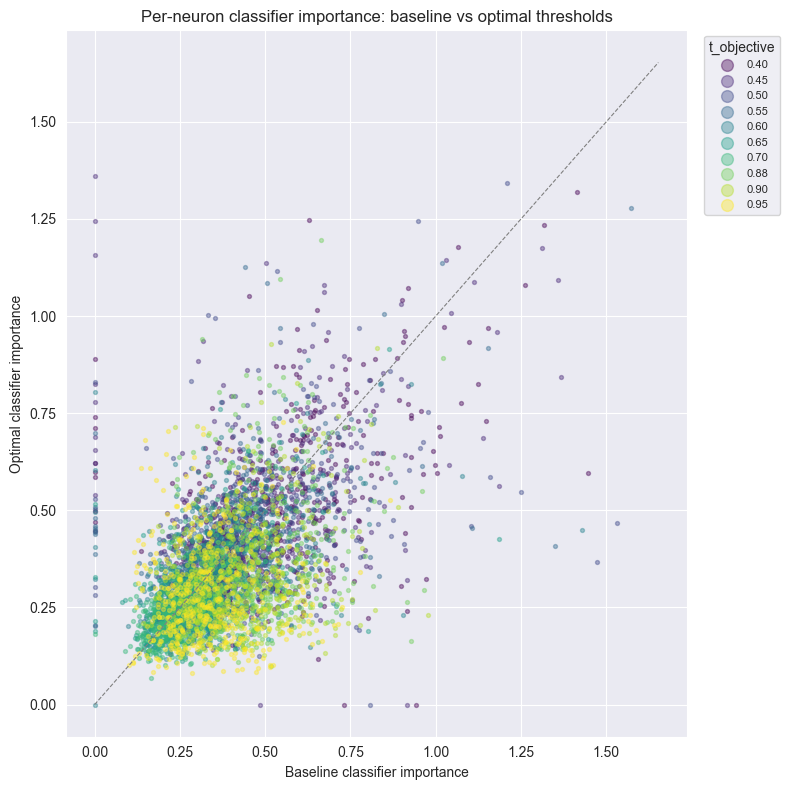

In [65]:
# Plot 11: Baseline importance vs optimal importance per neuron (where available)
# Colored by t_objective
has_importance = {
    t: seeds for t, seeds in optimal.items()
    if any("baseline_importance" in s and "optimal_importance" in s for s in seeds)
}

if has_importance:
    imp_tobjs = sorted(has_importance.keys())
    cmap_imp = plt.cm.viridis(np.linspace(0, 1, len(imp_tobjs)))

    fig, ax = plt.subplots(figsize=(8, 8))
    for tobj, color in zip(imp_tobjs, cmap_imp):
        for seed_result in has_importance[tobj]:
            if "baseline_importance" not in seed_result:
                continue
            bi = np.array(seed_result["baseline_importance"])
            oi = np.array(seed_result["optimal_importance"])
            ax.scatter(bi, oi, c=[color], s=8, alpha=0.4, label=f"{tobj:.2f}")

    # Deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="t_objective",
              bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=3)

    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, "--", color="gray", linewidth=0.8, label="y=x")
    ax.set_xlabel("Baseline classifier importance")
    ax.set_ylabel("Optimal classifier importance")
    ax.set_title("Per-neuron classifier importance: baseline vs optimal thresholds")
    plt.tight_layout()
    plt.show()
else:
    print("No importance data found in optimal_thresholds.json (skipping plot).")

## Predicting optimal threshold shifts from observable metrics

Which per-neuron metrics (from training or post-hoc inference) correlate with `optimal_deltas`? Can combinations of metrics predict them via multivariate regression?

In [66]:
# Load post-hoc metrics per seed per t_objective
post_hoc = {}
for tobj, dirname in zip(t_objectives, tobj_dirs):
    tobj_path = os.path.join(RESULTS_DIR, dirname)
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    seed_metrics = []
    for seed_dir in seed_dirs:
        ph_path = os.path.join(tobj_path, seed_dir, "post_hoc_metrics.json")
        if os.path.exists(ph_path):
            with open(ph_path) as f:
                seed_metrics.append(json.load(f))
    if seed_metrics:
        post_hoc[tobj] = seed_metrics

print(f"Post-hoc metrics available for {len(post_hoc)}/{len(t_objectives)} t_objectives")
for t in sorted(post_hoc):
    print(f"  t_obj={t:.3f}: {len(post_hoc[t])} seeds")

Post-hoc metrics available for 13/13 t_objectives
  t_obj=0.400: 5 seeds
  t_obj=0.450: 5 seeds
  t_obj=0.500: 5 seeds
  t_obj=0.550: 5 seeds
  t_obj=0.600: 5 seeds
  t_obj=0.650: 5 seeds
  t_obj=0.700: 5 seeds
  t_obj=0.750: 5 seeds
  t_obj=0.800: 5 seeds
  t_obj=0.850: 5 seeds
  t_obj=0.875: 5 seeds
  t_obj=0.900: 5 seeds
  t_obj=0.950: 5 seeds


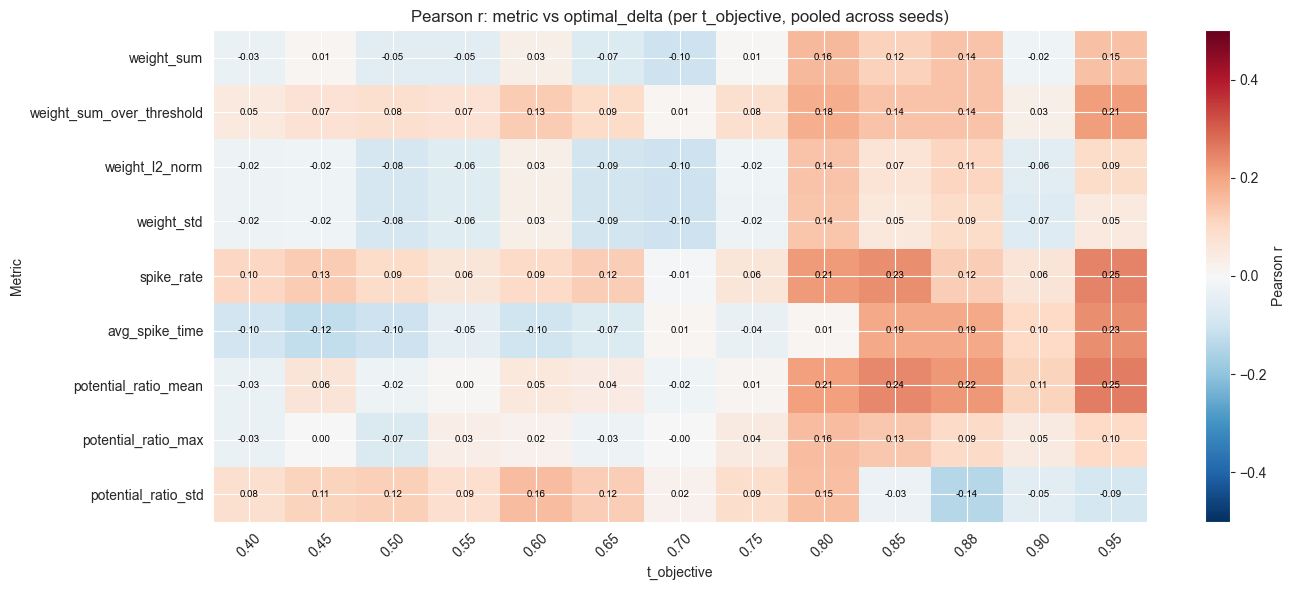

In [67]:
# Correlation heatmap: each metric vs optimal_deltas across t_objectives
# Weight-based metrics come from model weights (per-seed, 256 each); post-hoc from post_hoc_metrics.json

# Build per-seed weight-based metrics (split from concatenated arrays)
def _per_seed_weight_metrics(tobj, tobj_dirs_map):
    """Return list of dicts (one per seed) with weight_sum and weight_sum_over_threshold."""
    tobj_path = os.path.join(RESULTS_DIR, tobj_dirs_map[tobj])
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    result = []
    for seed_dir in seed_dirs:
        model_path = os.path.join(tobj_path, seed_dir, "model.pth")
        if not os.path.exists(model_path):
            continue
        model = load_model(model_path)
        layer = model.layers[0]
        weights = layer.weights.detach()
        thresholds = layer.thresholds.detach()
        wsums = weights.sum(dim=1).cpu().numpy()
        threshs = thresholds.cpu().numpy()
        result.append({
            "weight_sum": wsums.tolist(),
            "weight_sum_over_threshold": (wsums / threshs).tolist(),
        })
    return result

tobj_dirs_map = {float(d.split("_")[1]): d for d in tobj_dirs}

# Metrics to correlate (name, source)
metric_names = [
    "weight_sum", "weight_sum_over_threshold",
    "weight_l2_norm", "weight_std", "spike_rate",
    "avg_spike_time", "potential_ratio_mean", "potential_ratio_max", "potential_ratio_std",
]

# Only use t_objectives that have both perturbation and post-hoc data
common_tobjs = sorted(set(perturbation.keys()) & set(post_hoc.keys()))

corr_matrix = np.full((len(metric_names), len(common_tobjs)), np.nan)

for j, tobj in enumerate(common_tobjs):
    weight_seeds = _per_seed_weight_metrics(tobj, tobj_dirs_map)
    ph_seeds = post_hoc[tobj]
    perturb_seeds = perturbation[tobj]

    # Match seeds: use min count across sources
    n_seeds = min(len(weight_seeds), len(ph_seeds), len(perturb_seeds))

    for i, metric_name in enumerate(metric_names):
        all_metric_vals = []
        all_deltas = []
        for s in range(n_seeds):
            deltas = perturb_seeds[s]["optimal_deltas"]
            if metric_name in ("weight_sum", "weight_sum_over_threshold"):
                vals = weight_seeds[s][metric_name]
            else:
                vals = ph_seeds[s][metric_name]
            all_metric_vals.extend(vals)
            all_deltas.extend(deltas)

        # Filter out inf/nan
        arr_m = np.array(all_metric_vals, dtype=float)
        arr_d = np.array(all_deltas, dtype=float)
        valid = np.isfinite(arr_m) & np.isfinite(arr_d)
        if valid.sum() > 2:
            r, _ = stats.pearsonr(arr_m[valid], arr_d[valid])
            corr_matrix[i, j] = r

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(corr_matrix, aspect="auto", cmap="RdBu_r", vmin=-0.5, vmax=0.5)
for i in range(len(metric_names)):
    for j in range(len(common_tobjs)):
        val = corr_matrix[i, j]
        if np.isfinite(val):
            color = "white" if abs(val) > 0.3 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

ax.set_xticks(range(len(common_tobjs)))
ax.set_xticklabels([f"{t:.2f}" for t in common_tobjs], rotation=45)
ax.set_yticks(range(len(metric_names)))
ax.set_yticklabels(metric_names)
ax.set_xlabel("t_objective")
ax.set_ylabel("Metric")
ax.set_title("Pearson r: metric vs optimal_delta (per t_objective, pooled across seeds)")
fig.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

/var/folders/s2/81dpl6dd6xq1m2_npzc7ngcw0000gp/T/ipykernel_94345/672635527.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


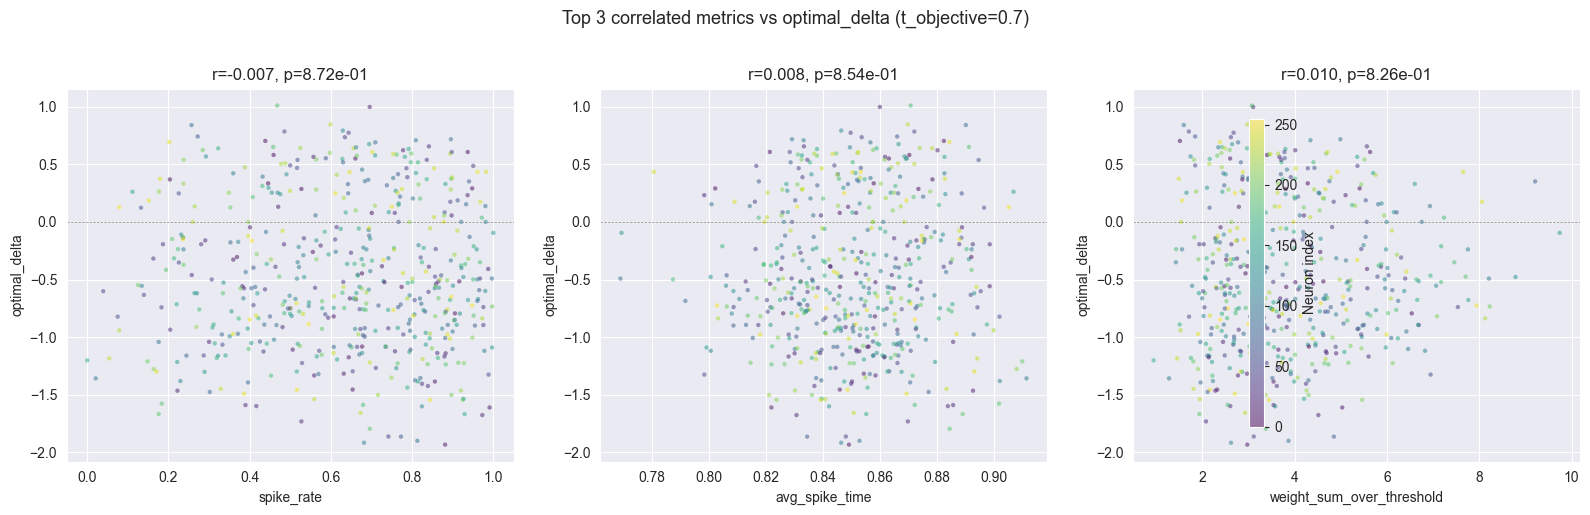

Top 3 metrics by mean |r|: ['spike_rate', 'avg_spike_time', 'weight_sum_over_threshold']
Mean |r| values: ['0.119', '0.100', '0.099']


In [68]:
# Scatter plots for top 3 metrics (by mean |r| across t_objectives) at representative t_objective
mean_abs_r = np.nanmean(np.abs(corr_matrix), axis=1)
top3_idx = np.argsort(mean_abs_r)[-3:][::-1]
top3_names = [metric_names[i] for i in top3_idx]

# Use the same representative t_objective as Experiment 3
rep_idx = common_tobjs.index(rep_tobj) if rep_tobj in common_tobjs else len(common_tobjs) // 2
rep_t = common_tobjs[rep_idx]

weight_seeds = _per_seed_weight_metrics(rep_t, tobj_dirs_map)
ph_seeds = post_hoc[rep_t]
perturb_seeds = perturbation[rep_t]
n_seeds = min(len(weight_seeds), len(ph_seeds), len(perturb_seeds))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric_name in zip(axes, top3_names):
    all_vals, all_deltas, all_neuron_idx = [], [], []
    for s in range(n_seeds):
        deltas = perturb_seeds[s]["optimal_deltas"]
        if metric_name in ("weight_sum", "weight_sum_over_threshold"):
            vals = weight_seeds[s][metric_name]
        else:
            vals = ph_seeds[s][metric_name]
        all_vals.extend(vals)
        all_deltas.extend(deltas)
        all_neuron_idx.extend(range(len(vals)))

    arr_v = np.array(all_vals, dtype=float)
    arr_d = np.array(all_deltas, dtype=float)
    arr_n = np.array(all_neuron_idx)
    valid = np.isfinite(arr_v) & np.isfinite(arr_d)

    sc = ax.scatter(arr_v[valid], arr_d[valid], c=arr_n[valid], cmap="viridis",
                    s=10, alpha=0.5, edgecolors="none")
    r_val, p_val = stats.pearsonr(arr_v[valid], arr_d[valid])
    ax.set_xlabel(metric_name)
    ax.set_ylabel("optimal_delta")
    ax.set_title(f"r={r_val:.3f}, p={p_val:.2e}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)

fig.suptitle(f"Top 3 correlated metrics vs optimal_delta (t_objective={rep_t})", fontsize=13, y=1.02)
fig.colorbar(sc, ax=axes, label="Neuron index", shrink=0.8)
plt.tight_layout()
plt.show()

print(f"Top 3 metrics by mean |r|: {top3_names}")
print(f"Mean |r| values: {[f'{mean_abs_r[i]:.3f}' for i in top3_idx]}")

In [69]:
# Multivariate linear regression: can combinations of metrics predict optimal_deltas?
from applications.threshold_research.analysis import compute_predictive_model

r_squared_by_tobj = {}
for tobj in common_tobjs:
    weight_seeds = _per_seed_weight_metrics(tobj, tobj_dirs_map)
    ph_seeds = post_hoc[tobj]
    perturb_seeds = perturbation[tobj]
    n_seeds = min(len(weight_seeds), len(ph_seeds), len(perturb_seeds))

    # Collect all metrics and deltas across seeds
    all_metrics = {name: [] for name in metric_names}
    all_deltas = []
    for s in range(n_seeds):
        all_deltas.extend(perturb_seeds[s]["optimal_deltas"])
        for name in metric_names:
            if name in ("weight_sum", "weight_sum_over_threshold"):
                all_metrics[name].extend(weight_seeds[s][name])
            else:
                all_metrics[name].extend(ph_seeds[s][name])

    # Filter out inf/nan across all metrics
    stacked = np.column_stack([np.array(all_metrics[n], dtype=float) for n in metric_names])
    deltas_arr = np.array(all_deltas, dtype=float)
    valid = np.all(np.isfinite(stacked), axis=1) & np.isfinite(deltas_arr)

    if valid.sum() > len(metric_names) + 1:
        filtered_metrics = {n: stacked[valid, i] for i, n in enumerate(metric_names)}
        result = compute_predictive_model(deltas_arr[valid], filtered_metrics)
        r_squared_by_tobj[tobj] = result["r_squared"]

# Print R² table
print(f"{'t_objective':>11} | {'R²':>8} | {'n_neurons':>9}")
print("-" * 35)
for tobj in common_tobjs:
    if tobj in r_squared_by_tobj:
        print(f"{tobj:11.2f} | {r_squared_by_tobj[tobj]:8.4f} | {valid.sum():9d}")
    else:
        print(f"{tobj:11.2f} | {'N/A':>8} |")

t_objective |       R² | n_neurons
-----------------------------------
       0.40 |   0.0618 |       512
       0.45 |   0.0433 |       512
       0.50 |   0.0784 |       512
       0.55 |   0.0417 |       512
       0.60 |   0.0302 |       512
       0.65 |   0.0851 |       512
       0.70 |   0.0267 |       512
       0.75 |   0.0315 |       512
       0.80 |   0.0744 |       512
       0.85 |   0.1032 |       512
       0.88 |   0.0602 |       512
       0.90 |   0.0469 |       512
       0.95 |   0.0943 |       512


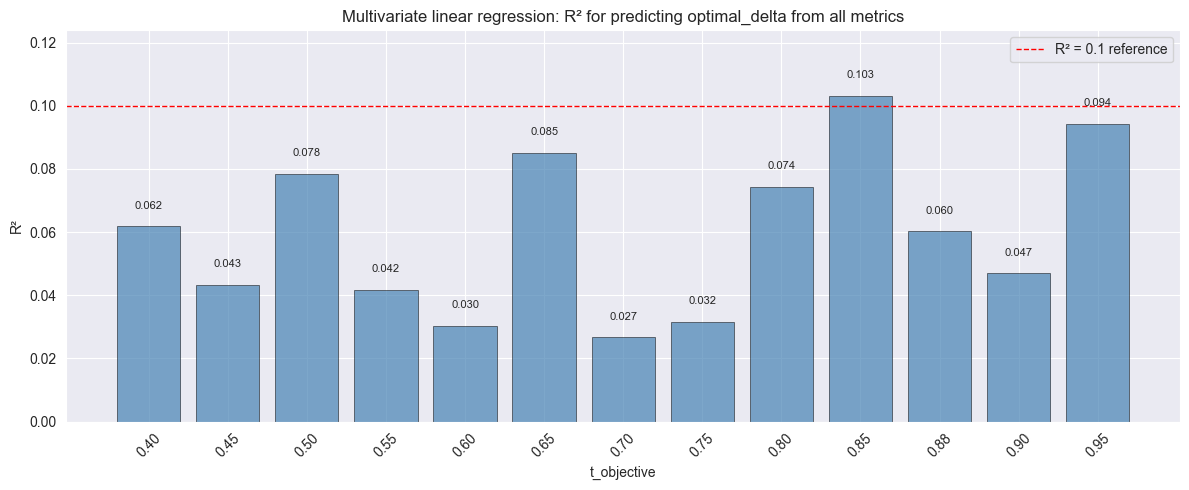

In [70]:
# R² bar chart per t_objective
fig, ax = plt.subplots(figsize=(12, 5))
tobjs_with_r2 = sorted(r_squared_by_tobj.keys())
r2_values = [r_squared_by_tobj[t] for t in tobjs_with_r2]

bars = ax.bar(range(len(tobjs_with_r2)), r2_values, color="steelblue", alpha=0.7,
              edgecolor="black", linewidth=0.5)
ax.axhline(0.1, color="red", linestyle="--", linewidth=1, label="R² = 0.1 reference")

for i, (t, r2) in enumerate(zip(tobjs_with_r2, r2_values)):
    ax.text(i, r2 + 0.005, f"{r2:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(tobjs_with_r2)))
ax.set_xticklabels([f"{t:.2f}" for t in tobjs_with_r2], rotation=45)
ax.set_xlabel("t_objective")
ax.set_ylabel("R²")
ax.set_title("Multivariate linear regression: R² for predicting optimal_delta from all metrics")
ax.legend()
ax.set_ylim(0, max(r2_values) * 1.2 if r2_values else 0.2)
plt.tight_layout()
plt.show()

# Linear Analysis: Negative Result

**Setup**: 12 per-neuron metrics across 13 t_objectives, 256 neurons × 2 seeds (512 samples per t_objective):
- **Post-hoc** (9): weight L1/L2/std, spike rate, avg spike time, potential ratio mean/max/std, weight sum, weight sum/threshold
- **Training-time** (3): spike counts, update counts, threshold drift

**Individual correlations**: Best single metric is `spike_rate` at mean |r| = 0.119. All others below 0.1. No single metric has meaningful linear predictive power.

**Multivariate linear R²**: 0.027–0.103 across t_objectives. Even combining all metrics, linear regression explains at most ~10% of variance in optimal threshold shifts.

**Structural insight**: Most neurons need threshold *decreases* (the original thresholds are too high). There is a phase transition around t_objective ≥ 0.85 where behavior changes qualitatively.

**Conclusion**: The metrics cannot linearly predict optimal threshold shifts. Next step: test whether the relationship is nonlinear (Gradient Boosting) or simply absent.

In [71]:
the# Nonlinear model comparison: Linear Regression vs Gradient Boosting (cross-validated)
# Include training-time metrics (spike_counts, update_counts, threshold_drift) alongside
# post-hoc and weight-based metrics for a more complete feature set.
from applications.threshold_research.analysis import compute_nonlinear_predictive_model

training_metric_names = ["spike_counts", "update_counts", "threshold_drift"]
all_metric_names = metric_names + training_metric_names

def _per_seed_training_metrics(tobj, tobj_dirs_map):
    """Return list of dicts (one per seed) with training-time per-neuron metrics."""
    tobj_path = os.path.join(RESULTS_DIR, tobj_dirs_map[tobj])
    seed_dirs = sorted(d for d in os.listdir(tobj_path) if d.startswith("seed_"))
    result = []
    for seed_dir in seed_dirs:
        path = os.path.join(tobj_path, seed_dir, "training_metrics.json")
        if os.path.exists(path):
            with open(path) as f:
                result.append(json.load(f))
    return result

nonlinear_results = {}
for tobj in common_tobjs:
    weight_seeds = _per_seed_weight_metrics(tobj, tobj_dirs_map)
    ph_seeds = post_hoc[tobj]
    perturb_seeds = perturbation[tobj]
    train_seeds = _per_seed_training_metrics(tobj, tobj_dirs_map)
    n_seeds = min(len(weight_seeds), len(ph_seeds), len(perturb_seeds), len(train_seeds))

    all_metrics = {name: [] for name in all_metric_names}
    all_deltas = []
    for s in range(n_seeds):
        all_deltas.extend(perturb_seeds[s]["optimal_deltas"])
        for name in all_metric_names:
            if name in ("weight_sum", "weight_sum_over_threshold"):
                all_metrics[name].extend(weight_seeds[s][name])
            elif name in training_metric_names:
                all_metrics[name].extend(train_seeds[s][name])
            else:
                all_metrics[name].extend(ph_seeds[s][name])

    # Filter out inf/nan across all metrics
    stacked = np.column_stack([np.array(all_metrics[n], dtype=float) for n in all_metric_names])
    deltas_arr = np.array(all_deltas, dtype=float)
    valid = np.all(np.isfinite(stacked), axis=1) & np.isfinite(deltas_arr)

    if valid.sum() > len(all_metric_names) + 1:
        filtered_metrics = {n: stacked[valid, i] for i, n in enumerate(all_metric_names)}
        result = compute_nonlinear_predictive_model(deltas_arr[valid], filtered_metrics)
        nonlinear_results[tobj] = result

# Print comparison table
print(f"Features ({len(all_metric_names)}): {all_metric_names}")
print()
print(f"{'t_obj':>6}  {'Linear CV R²':>14}  {'GBR CV R²':>14}  {'n_samples':>10}  {'n_features':>10}")
print("-" * 62)
for tobj in sorted(nonlinear_results.keys()):
    r = nonlinear_results[tobj]
    print(f"{tobj:6.2f}  {r['linear_cv_r2']:7.4f} ± {r['linear_cv_r2_std']:.4f}"
          f"  {r['gbr_cv_r2']:7.4f} ± {r['gbr_cv_r2_std']:.4f}"
          f"  {r['n_samples']:10d}  {r['n_features']:10d}")

Features (12): ['weight_sum', 'weight_sum_over_threshold', 'weight_l2_norm', 'weight_std', 'spike_rate', 'avg_spike_time', 'potential_ratio_mean', 'potential_ratio_max', 'potential_ratio_std', 'spike_counts', 'update_counts', 'threshold_drift']

 t_obj    Linear CV R²       GBR CV R²   n_samples  n_features
--------------------------------------------------------------
  0.40   0.0121 ± 0.0197  -0.0977 ± 0.0536         503          12
  0.45  -0.0740 ± 0.1029  -0.1709 ± 0.1377         503          12
  0.50   0.0163 ± 0.0407  -0.0270 ± 0.0409         507          12
  0.55  -0.0179 ± 0.0363  -0.1688 ± 0.0769         501          12
  0.60  -0.0443 ± 0.0437  -0.1701 ± 0.0622         506          12
  0.65   0.0115 ± 0.0567  -0.1200 ± 0.0672         508          12
  0.70  -0.0887 ± 0.0265  -0.2293 ± 0.1550         511          12
  0.75  -0.0750 ± 0.0716  -0.1927 ± 0.1053         512          12
  0.80   0.0023 ± 0.0609  -0.1320 ± 0.0664         512          12
  0.85  -0.0828 ± 0.1567 

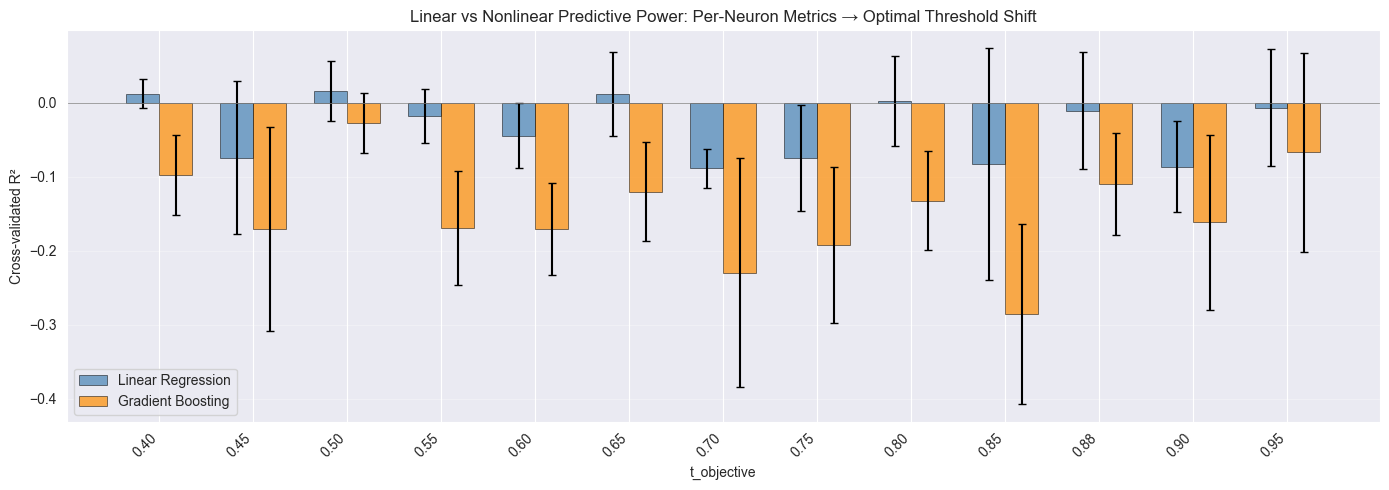

In [72]:
# Side-by-side bar chart: Linear vs GBR cross-validated R²
tobjs_sorted = sorted(nonlinear_results.keys())
linear_r2 = [nonlinear_results[t]["linear_cv_r2"] for t in tobjs_sorted]
linear_std = [nonlinear_results[t]["linear_cv_r2_std"] for t in tobjs_sorted]
gbr_r2 = [nonlinear_results[t]["gbr_cv_r2"] for t in tobjs_sorted]
gbr_std = [nonlinear_results[t]["gbr_cv_r2_std"] for t in tobjs_sorted]

x = np.arange(len(tobjs_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width / 2, linear_r2, width, yerr=linear_std,
               label="Linear Regression", color="steelblue", alpha=0.7,
               edgecolor="black", linewidth=0.5, capsize=3)
bars2 = ax.bar(x + width / 2, gbr_r2, width, yerr=gbr_std,
               label="Gradient Boosting", color="darkorange", alpha=0.7,
               edgecolor="black", linewidth=0.5, capsize=3)

ax.axhline(0, color="gray", linestyle="-", linewidth=0.5)
ax.set_xlabel("t_objective")
ax.set_ylabel("Cross-validated R²")
ax.set_title("Linear vs Nonlinear Predictive Power: Per-Neuron Metrics → Optimal Threshold Shift")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in tobjs_sorted], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Alternative Evaluation Strategies

The Ridge refit approach produces tiny accuracy differences (mean ~0.0004, max range ~0.0037 per neuron) because the classifier compensates for single-neuron threshold changes by re-fitting. The "optimal deltas" are essentially picking between noise.

Two alternatives that should produce a cleaner signal:
1. **No-refit Ridge**: Use the baseline classifier to score perturbed features without re-fitting. Measures direct sensitivity of classification to threshold changes.
2. **NearestCentroid refit**: Weak classifier that can't compensate well for perturbations. Still re-fits but should produce larger accuracy differences.

In [ ]:
# Compare evaluation strategies: Ridge refit vs no-refit vs NearestCentroid refit
from sklearn.neighbors import NearestCentroid
from applications.threshold_research.neuron_perturbation import (
    evaluate_perturbations,
    _load_feature_cache,
)

strategies = {
    "Ridge refit": dict(),  # defaults
    "Ridge no-refit": dict(refit=False),
    "NearestCentroid refit": dict(classifier_factory=lambda: NearestCentroid()),
}

strategy_results = {}
for tobj in t_objectives:
    tobj_dir = os.path.join(RESULTS_DIR, f"tobj_{tobj:.2f}")
    seed_dirs = sorted(d for d in os.listdir(tobj_dir) if d.startswith("seed_"))
    for seed_dir in seed_dirs:
        cache_dir = os.path.join(tobj_dir, seed_dir, "perturbation_cache")
        if not os.path.exists(os.path.join(cache_dir, "metadata.json")):
            continue
        features = _load_feature_cache(cache_dir)
        key = (tobj, seed_dir)
        strategy_results[key] = {}
        for name, kwargs in strategies.items():
            result = evaluate_perturbations(features=features, **kwargs)
            acc = np.array(result["accuracy_matrix"])
            ranges = np.ptp(acc, axis=1)
            strategy_results[key][name] = {
                "mean_range": ranges.mean(),
                "max_range": ranges.max(),
                "mean_std": acc.std(axis=1).mean(),
                "optimal_deltas": result["optimal_deltas"],
                "baseline_acc": result["baseline"]["accuracy"],
            }

# Print comparison table
print(f"{'Strategy':<25} {'Mean range':>12} {'Max range':>12} {'Mean std':>12}")
print("-" * 65)
for name in strategies:
    mean_ranges = [v[name]["mean_range"] for v in strategy_results.values()]
    max_ranges = [v[name]["max_range"] for v in strategy_results.values()]
    mean_stds = [v[name]["mean_std"] for v in strategy_results.values()]
    print(f"{name:<25} {np.mean(mean_ranges):>12.6f} {np.mean(max_ranges):>12.6f} {np.mean(mean_stds):>12.6f}")

In [ ]:
# Re-run nonlinear predictive model with optimal deltas from best alternative strategy
# Pick the strategy with the largest mean accuracy range
best_strategy = max(strategies.keys(), key=lambda name: np.mean(
    [v[name]["mean_range"] for v in strategy_results.values()]
))
print(f"Best strategy by mean accuracy range: {best_strategy}")

alt_nonlinear_results = {}
for tobj in t_objectives:
    tobj_dir = os.path.join(RESULTS_DIR, f"tobj_{tobj:.2f}")
    seed_dirs = sorted(d for d in os.listdir(tobj_dir) if d.startswith("seed_"))

    all_deltas = []
    all_metrics_per_key = {}

    for seed_dir in seed_dirs:
        key = (tobj, seed_dir)
        if key not in strategy_results:
            continue
        deltas = strategy_results[key][best_strategy]["optimal_deltas"]
        all_deltas.extend(deltas)

        # Load the same metrics used in the original nonlinear analysis
        seed_path = os.path.join(tobj_dir, seed_dir)
        post_hoc_path = os.path.join(seed_path, "post_hoc_metrics.json")
        training_path = os.path.join(seed_path, "training_metrics.json")
        if not os.path.exists(post_hoc_path):
            continue

        with open(post_hoc_path) as f:
            ph = json.load(f)
        tm = {}
        if os.path.exists(training_path):
            with open(training_path) as f:
                tm = json.load(f)

        for mname in all_metric_names:
            vals = ph.get(mname, tm.get(mname, None))
            if vals is not None:
                all_metrics_per_key.setdefault(mname, []).extend(vals)

    if not all_deltas or not all_metrics_per_key:
        continue

    deltas_arr = np.array(all_deltas)
    valid = np.isfinite(deltas_arr)
    filtered_metrics = {}
    for mname, vals in all_metrics_per_key.items():
        arr = np.array(vals)
        if len(arr) == len(deltas_arr):
            filtered_metrics[mname] = arr[valid]

    if filtered_metrics and valid.sum() > 10:
        result = compute_nonlinear_predictive_model(deltas_arr[valid], filtered_metrics)
        alt_nonlinear_results[tobj] = result

# Compare original vs alternative strategy R² values
print(f"\n{'t_obj':>6} | {'Orig Linear R²':>15} {'Orig GBR R²':>12} | {best_strategy + ' Linear R²':>25} {best_strategy + ' GBR R²':>20}")
print("-" * 100)
for tobj in sorted(set(list(nonlinear_results.keys()) + list(alt_nonlinear_results.keys()))):
    orig = nonlinear_results.get(tobj, {})
    alt = alt_nonlinear_results.get(tobj, {})
    orig_lin = f"{orig.get('linear_cv_r2', float('nan')):>15.4f}" if orig else f"{'N/A':>15}"
    orig_gbr = f"{orig.get('gbr_cv_r2', float('nan')):>12.4f}" if orig else f"{'N/A':>12}"
    alt_lin = f"{alt.get('linear_cv_r2', float('nan')):>25.4f}" if alt else f"{'N/A':>25}"
    alt_gbr = f"{alt.get('gbr_cv_r2', float('nan')):>20.4f}" if alt else f"{'N/A':>20}"
    print(f"{tobj:>6.2f} | {orig_lin} {orig_gbr} | {alt_lin} {alt_gbr}")